In [123]:
%pip install pandas matplotlib plotly seaborn numpy

Note: you may need to restart the kernel to use updated packages.


In [124]:
import os
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import plotly.express as px
import seaborn as sns
import numpy as np

# Importazione dei dati


In [3]:
path="clean_datasets"

In [92]:
# Load datasets
try:
    df_actors = pd.read_csv(os.path.join(path, "df_actors.csv"))
    df_countries = pd.read_csv(os.path.join(path, "df_countries.csv"))
    df_crew = pd.read_csv(os.path.join(path, "df_crew.csv"))
    df_released_movies = pd.read_csv(os.path.join(path, "df_released_movies.csv"))
    df_unreleased_movies = pd.read_csv(os.path.join(path, "df_unreleased_movies.csv"))
    df_movies = pd.read_csv(os.path.join(path, "df_movies.csv"))
    df_languages = pd.read_csv(os.path.join(path, "df_languages.csv"))
    df_posters = pd.read_csv(os.path.join(path, "df_posters.csv"))
    df_releases = pd.read_csv(os.path.join(path, "df_releases.csv"))
    df_themes = pd.read_csv(os.path.join(path, "df_themes.csv"))
    df_genres = pd.read_csv(os.path.join(path, "df_genres.csv"))
    df_studios = pd.read_csv(os.path.join(path, "df_studios.csv"))
    df_tomatoes= pd.read_csv(os.path.join(path, "df_tomatoes.csv"))
    df_oscars = pd.read_csv(os.path.join(path, "df_oscars.csv"))
except Exception as e:
    print(e)

# **Analisi dei Dati**


## Trend di popolarità (rating) dei film nel tempo

- Come è cambiato il rating del pubblico dei film nel tempo?
- Come è cambiato il rating della critica dei film nel tempo?
- Quali sono state le cause di questo cambiamento?
- Il rating dei film è influenzato anche da altri fattori? Proviamo a trovare correlazioni con il genere e con la durata


In [72]:
df_released_movies

,id,name,date,tagline,description,minute,rating,name_norm
0,1000001,Barbie,2023.0,She's everything. He's just Ken.,Barbie and Ken are having the time of their li...,114.0,3.86,barbie
1,1000002,Parasite,2019.0,Act like you own the place.,"All unemployed, Ki-taek's family takes peculia...",133.0,4.56,parasite
2,1000003,Everything Everywhere All at Once,2022.0,The universe is so much bigger than you realize.,An aging Chinese immigrant is swept up in an i...,140.0,4.30,everything everywhere all at once
3,1000004,Fight Club,1999.0,Mischief. Mayhem. Soap.,A ticking-time-bomb insomniac and a slippery s...,139.0,4.27,fight club
4,1000005,La La Land,2016.0,Here's to the fools who dream.,"Mia, an aspiring actress, serves lattes to mov...",129.0,4.09,la la land
...,...,...,...,...,...,...,...,...
826012,1940967,A Nursery In Paris,1909.0,NaN,Short film showing a nursery.,2.0,NaN,a nursery in paris
826013,1940968,I klädloge och på scen,1908.0,NaN,Miss Inga Berentz dresses up for the entrance....,7.0,NaN,i klädloge och på scen
826014,1940969,Danse fantaisiste,1902.0,NaN,"""Danse fantaisiste"" (Gaumont #589) is part of ...",NaN,NaN,danse fantaisiste
826015,1940970,La Gigue,1902.0,NaN,"""La Gigue"" (Gaumont #590) is part of the ""Miss...",NaN,NaN,la gigue


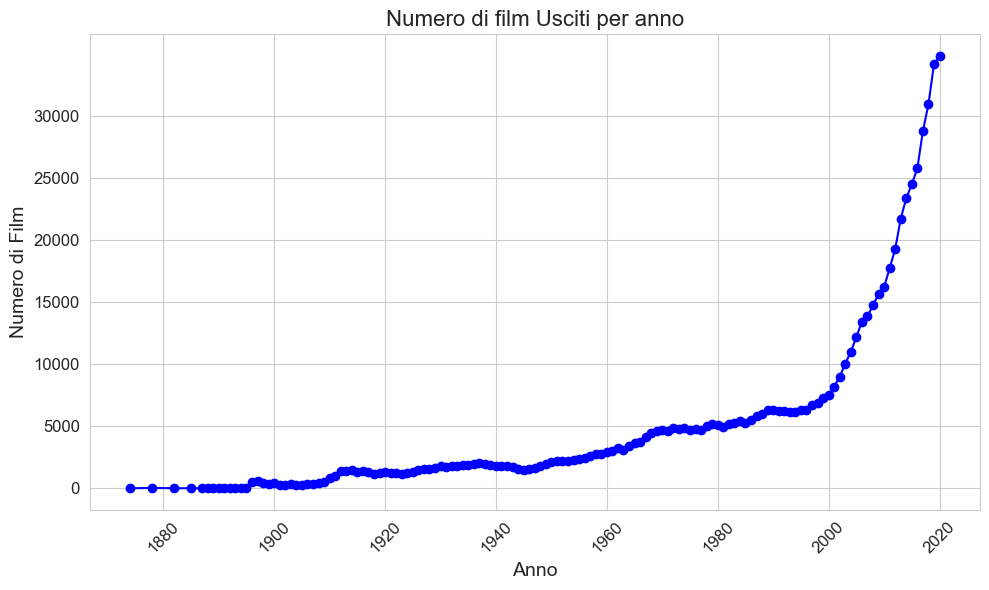

In [ ]:
films_per_year = df_released_movies.copy()
films_per_year = films_per_year[(films_per_year['date'] >= 1830) & (films_per_year['date'] <= 2020)]
films_per_year = films_per_year.groupby("date").size()

plt.figure(figsize=(10, 6))
plt.plot(films_per_year.index, films_per_year.values, marker='o', linestyle='-', color='blue', label="Numero di Film")

plt.title("Numero di film Usciti per anno", fontsize=16)
plt.xlabel("Anno", fontsize=14)
plt.ylabel("Numero di Film", fontsize=14)
plt.xticks(fontsize=12, rotation=45)
max_y = films_per_year.max()
yticks = list(range(0, max_y + 10, 5000))  
plt.yticks(yticks, fontsize=12)
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

Vi è stato un chiaro incremento nel tempo nel numero di film prodotti per anno, fino ad un improvviso crollo, che possiamo attribuire probabilmente alla nascita e all'evoluzione del Covid degli anni recenti.

Ora possiamo analizzare come invece si è evoluta in media la valutazione de film nei diversi anni da parte della critica.


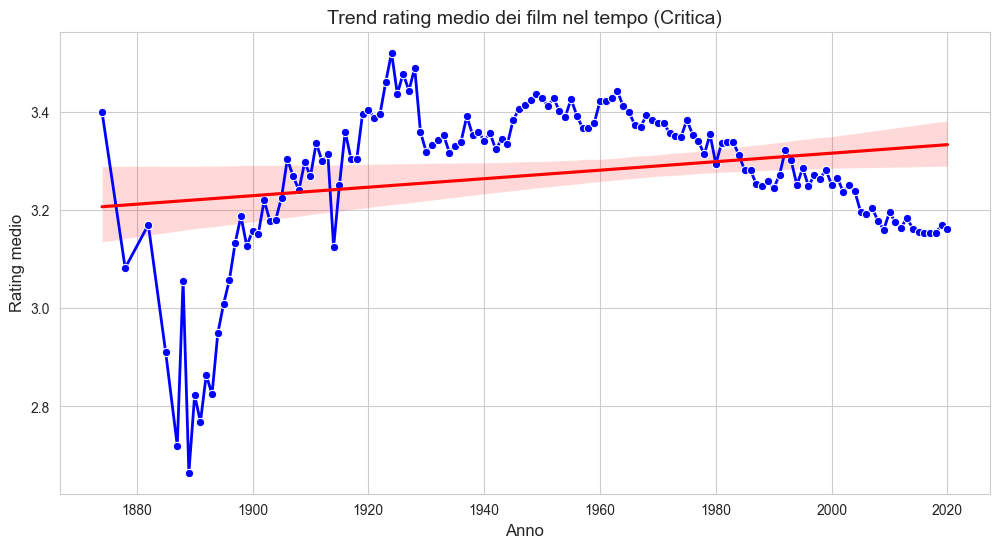

In [ ]:
rating_trend = df_released_movies.groupby('date')['rating'].mean().reset_index()
rating_trend = rating_trend[(rating_trend['date'] >= 1830) & (rating_trend['date'] <= 2020)]

plt.figure(figsize=(12,6))
sns.lineplot(data=rating_trend, x='date', y='rating', marker='o', linewidth=2, color='b')
sns.regplot(x=rating_trend['date'], y=rating_trend['rating'], scatter=False, color="red", label="Trend")
plt.title("Trend rating medio dei film nel tempo (Critica)", fontsize=14)
plt.xlabel("Anno", fontsize=12)
plt.ylabel("Rating medio", fontsize=12)
plt.grid(True, linestyle='--')
plt.show()

Negli inizi degli anni tra il 1920 e il 1940 abbiamo un picco di rating medio, mentre da quel punto possiamo notare un lento calo nelle valutazioni effettuate dal pubblico.


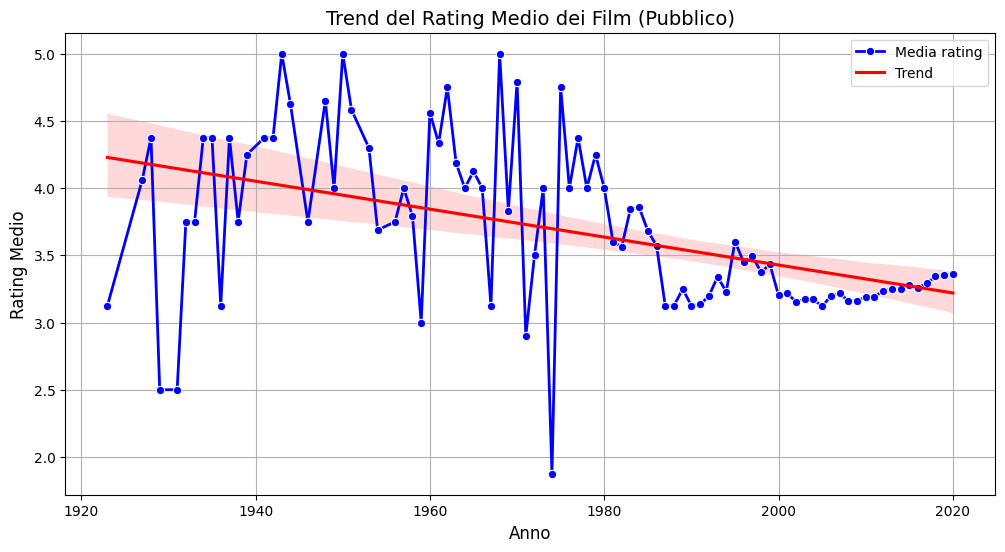

In [ ]:
rating_trend = df_tomatoes.copy()

rating_trend['year'] = pd.to_datetime(rating_trend['review_date'], errors='coerce').dt.year

rating_trend = rating_trend[(rating_trend['year'] >= 1830) & (rating_trend['year'] <= 2025)]
rating_trend = rating_trend.groupby('year')['rating'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=rating_trend['year'], y=rating_trend['rating'], marker="o",linewidth=2, color='b', label="Media rating")
sns.regplot(x=rating_trend['year'], y=rating_trend['rating'], scatter=False, color="red", label="Trend")
plt.title("Trend del Rating Medio dei Film (Pubblico)", fontsize=14)
plt.xlabel("Anno", fontsize=12)
plt.ylabel("Rating Medio", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

Possiamo notare come anche i rating dei critici siano stato in calo durante il tempo, fino ad una quasi stabilizzazione negli anni più recenti, questo però nota come i valori da parte dei critici siano diversi rispetto a quello del pubblico.
Quindi anche se in comune vi è il tranding verso il basso, i critici annualmente,in media, anche assegnato generalmente valori più alti come rating verso i film in uscita.
Perciò possiamo intuire che sia il pubblico che ha sviluppato un particolare per cui la popolarità dei film sia diminuita nel tempo.


Ci concentreremo principalmente sull'analisi dei rating del pubblico, per analizzare una valutazione più ampia.
Utiliziamo diversi boxplot per esplicitare la distribuzione del rating nel tempo.


/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_28014/785044821.py:12: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_28014/785044821.py:15: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



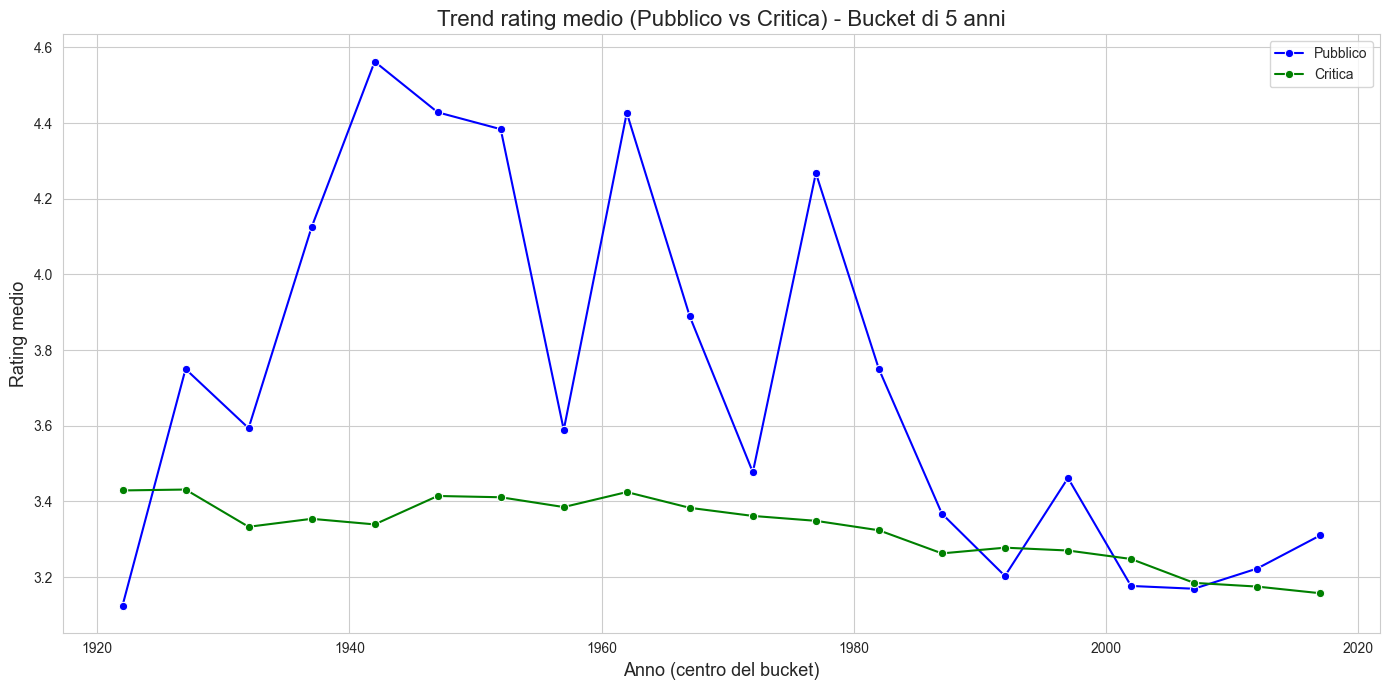

In [ ]:
rating_public = df_tomatoes.copy()
rating_public['year'] = pd.to_datetime(rating_public['review_date'], errors='coerce').dt.year
rating_public = rating_public[(rating_public['year'] >= 1920) & (rating_public['year'] <= 2025)]

rating_critics = df_released_movies.copy()
rating_critics = rating_critics.rename(columns={'rating': 'critics_rating', 'date': 'year'})

bins = list(range(1920, 2025, 5))  # fino al 2020
rating_public['year_bin'] = pd.cut(rating_public['year'], bins=bins, right=False)
rating_critics['year_bin'] = pd.cut(rating_critics['year'], bins=bins, right=False)

public_avg = rating_public.groupby('year_bin')['rating'].mean().reset_index()
public_avg.rename(columns={'rating': 'public_rating'}, inplace=True)

critics_avg = rating_critics.groupby('year_bin')['critics_rating'].mean().reset_index()

merged_rating = pd.merge(public_avg, critics_avg, on='year_bin', how='inner')

merged_rating['year_mid'] = merged_rating['year_bin'].apply(lambda x: x.left + 2)

plt.figure(figsize=(14, 7))
sns.lineplot(x='year_mid', y='public_rating', data=merged_rating, marker='o', color='blue', label='Pubblico')
sns.lineplot(x='year_mid', y='critics_rating', data=merged_rating, marker='o', color='green', label='Critica')

plt.title("Trend rating medio (Pubblico vs Critica) - Bucket di 5 anni", fontsize=16)
plt.xlabel("Anno (centro del bucket)", fontsize=13)
plt.ylabel("Rating medio", fontsize=13)
plt.legend()
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()


Se il rating medio della critica dal 1920 fino ad oggi è pressochè stabile con un lieve calo dal 1960 in poi, possiamo notare come invece il rating del pubblico varia spesso di anno in anno, probabilmente perchè i gusti cambiano e


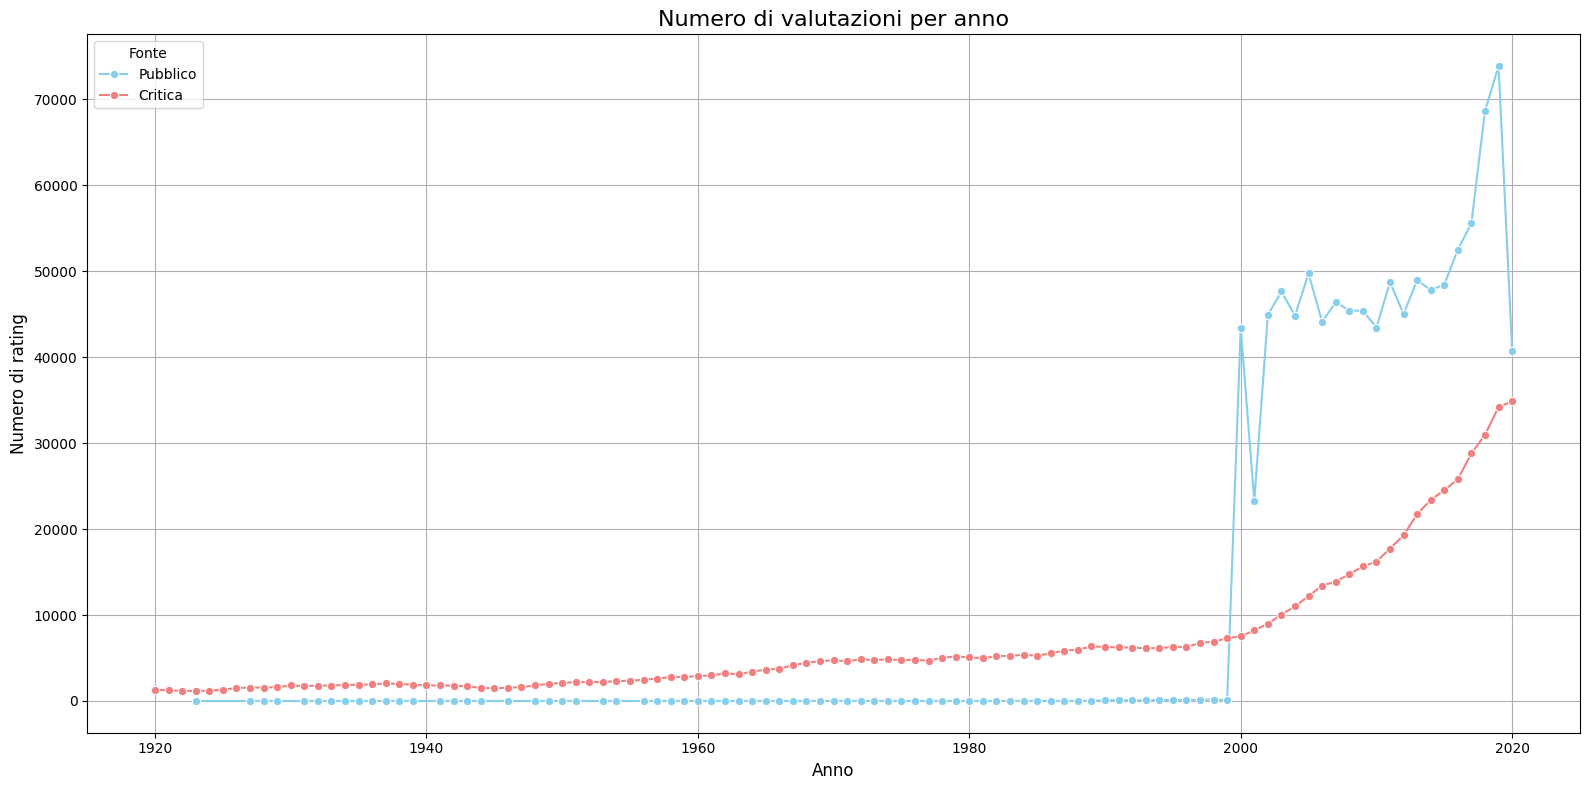

In [ ]:
public = df_tomatoes.copy()
public['year'] = pd.to_datetime(public['review_date'], errors='coerce').dt.year
public = public.dropna(subset=['year'])
public['year'] = public['year'].astype(int)
public = public[(public['year'] >= 1920) & (public['year'] <= 2020)]
public_counts = public.groupby('year').size().reset_index(name='count')
public_counts['source'] = 'Pubblico'

critics = df_released_movies.copy()
critics = critics.dropna(subset=['date'])
critics['year'] = critics['date'].astype(int)
critics = critics[(critics['year'] >= 1920) & (critics['year'] <= 2020)]
critics_counts = critics.groupby('year').size().reset_index(name='count')
critics_counts['source'] = 'Critica'

df_counts = pd.concat([public_counts, critics_counts], ignore_index=True)

plt.figure(figsize=(16, 8))
sns.lineplot(data=df_counts, x='year', y='count', hue='source', marker='o', palette={'Pubblico': 'skyblue', 'Critica': 'lightcoral'})

plt.title("Numero di valutazioni per anno", fontsize=16)
plt.xlabel("Anno", fontsize=12)
plt.ylabel("Numero di rating", fontsize=12)
plt.legend(title="Fonte")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Abbiamo dedotto quindi che nel nostro dataset non sono presenti un significativo numero di valutazioni del pubblico prima del 2000. La parte interessante quindi è dal 2000 in poi, e come possiamo vedere dal grafico precedente le linee del rating medio tra critica e pubblico si stabilizza pressochè sullo stesso valore.

Possiamo dedurre che i gusti del pubblico e dei critici si allineano, negli ultimi anni.


## Proviamo a scoprire, nonostante le poche valutazioni per il giudizio del pubblico, alcuni fattori di correlazione tra il rating e il genere

Esiste un genere che sbilancia in positivo o in negativo il rating medio per periodo?


In [10]:
movies_genres = pd.merge(df_released_movies, df_genres, left_on="id", right_on="id_film", how="inner")
movies_genres = movies_genres.sort_values(by=['id', 'genre']).drop_duplicates(subset=['id'], keep='first')

rating_medio = df_tomatoes.groupby('movie_title')['rating'].mean().reset_index()
altri_dati = df_tomatoes.drop(columns=['rating']).drop_duplicates(subset=['movie_title'], keep='first')
df_unificato = pd.merge(altri_dati, rating_medio, on='movie_title', how='inner')

moviessss = pd.merge(movies_genres, df_unificato, left_on="name", right_on="movie_title", how="inner")

top_genres = moviessss["genre"].value_counts().nlargest(10).index
filtered_movies = moviessss[moviessss["genre"].isin(top_genres)]

df_meltato = filtered_movies.melt(
    id_vars=['genre'],
    value_vars=['rating_x', 'rating_y'],  # rating_x = critica, rating_y = pubblico
    var_name='Rating_Type',
    value_name='Rating'
)


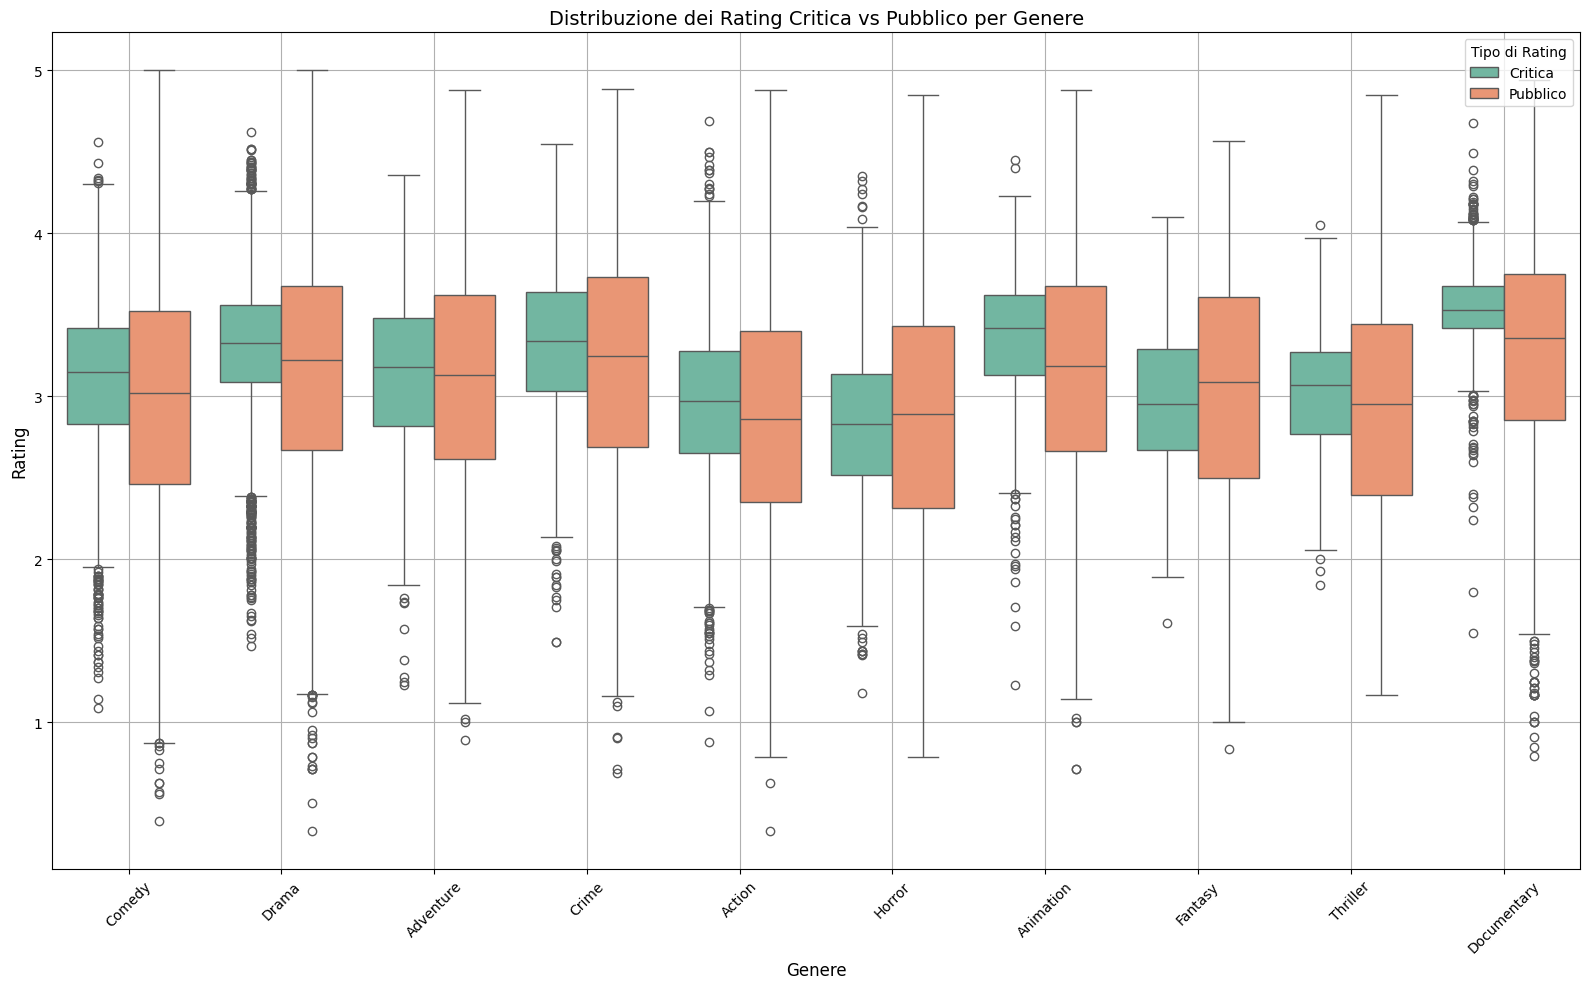

In [ ]:
custom_palette = {
    'rating_x': '#66c2a5',  # verde acqua (Critica)
    'rating_y': '#fc8d62',  # arancione (Pubblico)
}

plt.figure(figsize=(16, 10))

ax = sns.boxplot(
    data=df_meltato,
    x="genre",
    y="Rating",
    hue="Rating_Type",
    palette=custom_palette
)

handles, labels = ax.get_legend_handles_labels()

plt.title("Distribuzione dei Rating Critica vs Pubblico per Genere", fontsize=14)
plt.xlabel("Genere", fontsize=12)
plt.ylabel("Rating", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

plt.legend(
    handles=handles,
    labels=["Critica", "Pubblico"],
    title="Tipo di Rating",
    loc='upper right'
)

plt.tight_layout()
plt.show()

Vediamo come chiaramente i documentari sono il genere che ha mantenuto una media delle valutazioni più alta durante gli anni, assieme alla musica.
Tutti i generi nella prima fascia temporale hanno una mediana simile (3.0 - 3.5) quindi possiamo dedurre che i cambiamenti sono avvenuti solo successivamente.
La musica è l'unico genere che ha avuto una continua crescita, mentre gli altri generi dopo una crescita iniziale hanno avuto un calo finale rispetto al loro inizio.
In ogni genere notiamo però come la presenza di outsider negativi sia aumentata nel tempo.
Capiamo quindi che vi è una correlazione tra il genere di un film e il suo rating.


Tornando al primo grafico sul numero di film pubblicati nel tempo,potremmo pensare che la causa di questo calo di valutazioni sia data dal continuo aumento nel numero di film che vengono prodotti.
Un numero ingente di film ogni anno porterebbe ad una possibile ripetitività nei film che di conseguenza annoierebbe lo spettatore medio.


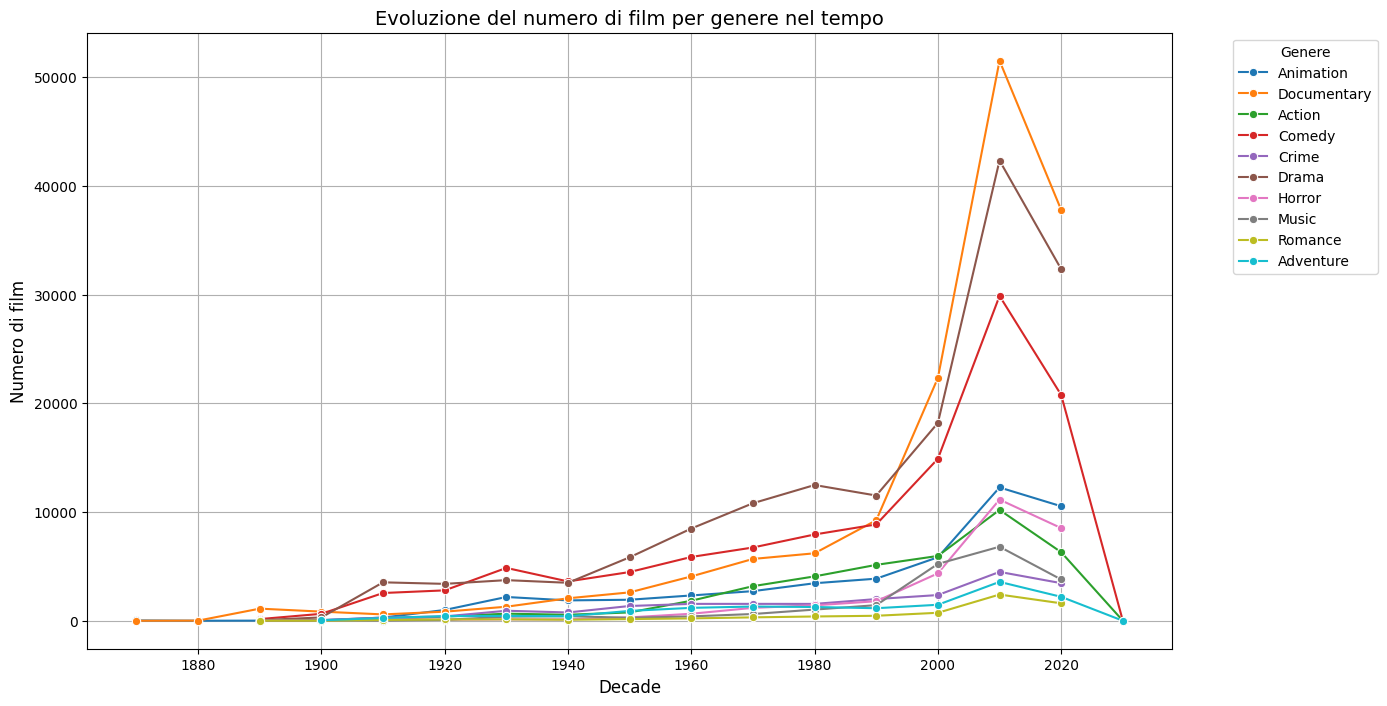

In [ ]:
movies_genres['decade'] = (movies_genres['date'] // 10) * 10
genre_trend = movies_genres.groupby(['decade', 'genre']).size().reset_index(name='film_count')

top_genres = movies_genres["genre"].value_counts().nlargest(10).index
filtered_trend = genre_trend[genre_trend['genre'].isin(top_genres)]

plt.figure(figsize=(14, 8))
sns.lineplot(data=filtered_trend, x="decade", y="film_count", hue="genre", marker="o")
plt.title("Evoluzione del numero di film per genere nel tempo", fontsize=14)
plt.xlabel("Decade", fontsize=12)
plt.ylabel("Numero di film", fontsize=12)
plt.legend(title="Genere", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--')
plt.show()

Vi è una crescita sostanziale tra il numero di film pubblicati, possiamo verificare se vi è una dipendenza con il rating per chiederci se producendo un numero maggiore di film la loro qualità diminuisca.


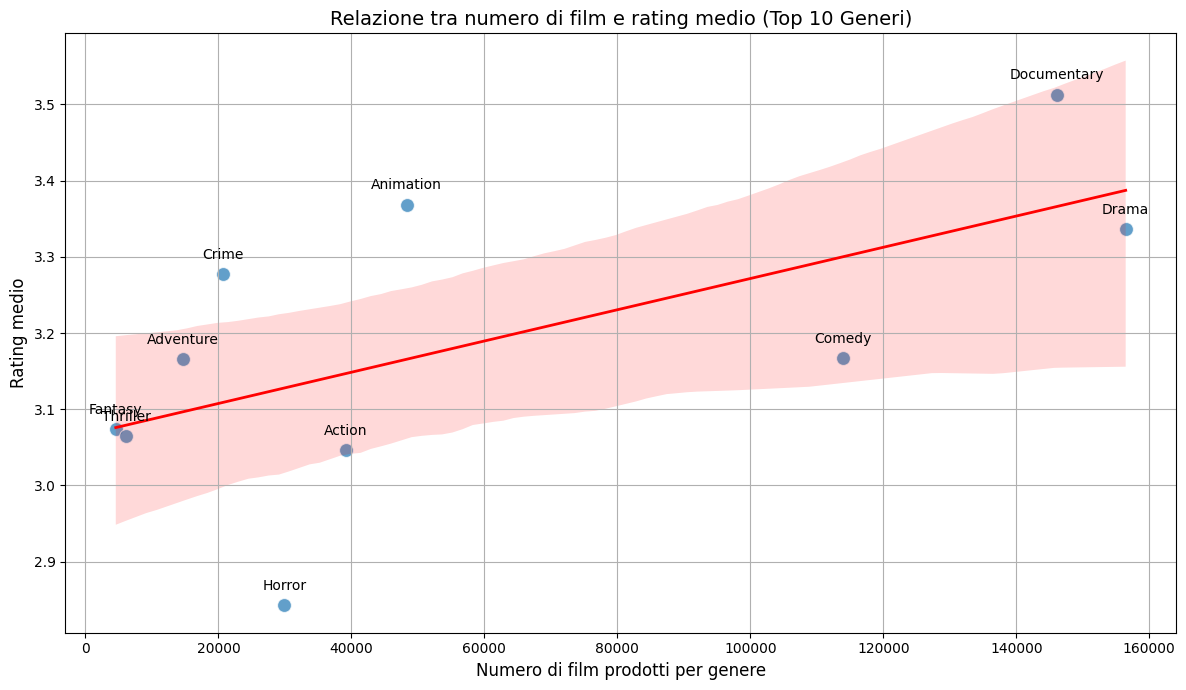

In [ ]:
top_genres = moviessss["genre"].value_counts().nlargest(10).index

genre_stats_top = movies_genres[movies_genres["genre"].isin(top_genres)].groupby("genre").agg(
    film_count=("id_film", "count"),
    avg_rating=("rating", "mean")
).reset_index()

plt.figure(figsize=(12, 7))

sns.scatterplot(data=genre_stats_top, x="film_count", y="avg_rating", alpha=0.7, s=100)

sns.regplot(data=genre_stats_top, x="film_count", y="avg_rating", scatter=False, color="red", line_kws={"linewidth": 2})

plt.title("Relazione tra numero di film e rating medio (Top 10 Generi)", fontsize=14)
plt.xlabel("Numero di film prodotti per genere", fontsize=12)
plt.ylabel("Rating medio", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

for i, row in genre_stats_top.iterrows():
    plt.text(row["film_count"], row["avg_rating"] + 0.02, row["genre"], fontsize=10, ha='center')

plt.tight_layout()
plt.show()


Per rispondere alla nostra domanda precedente, notiamo che in realtà la correlazione è leggermente positiva (linea rossa in crescita), quindi anche se il numero di film di genere aumenta, la maggior parte dei rating medi tende a salire.
Per esempio il Drama è il genere più prolifico, perchè con un vasto numero di film prodotti mantiene un rating medio del 3.3 .
Notiamo che i Documentari hanno il rating medio più alto mentre gli Horror quello minore.
Quindi non vediamo un chiaro calo del rating, generi molto prodotti riescono a mantenere abbastanza un buon rating medio, mentre quelli meno prodotti hanno rating più alti ma con molta variabilità.


Resta però che anche se in piccola quantità, la quantità di film prodotti per genere impatta il voto medio, probabilmente a causa di una minore attenzione alla qualità dei film stessi.


Possiamo pensare però che sia la durata dei film stessi a incidere sul loro rating, quindi film più lunghi possono avere valutazioni peggiori o migliori.


/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_28014/1987243220.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



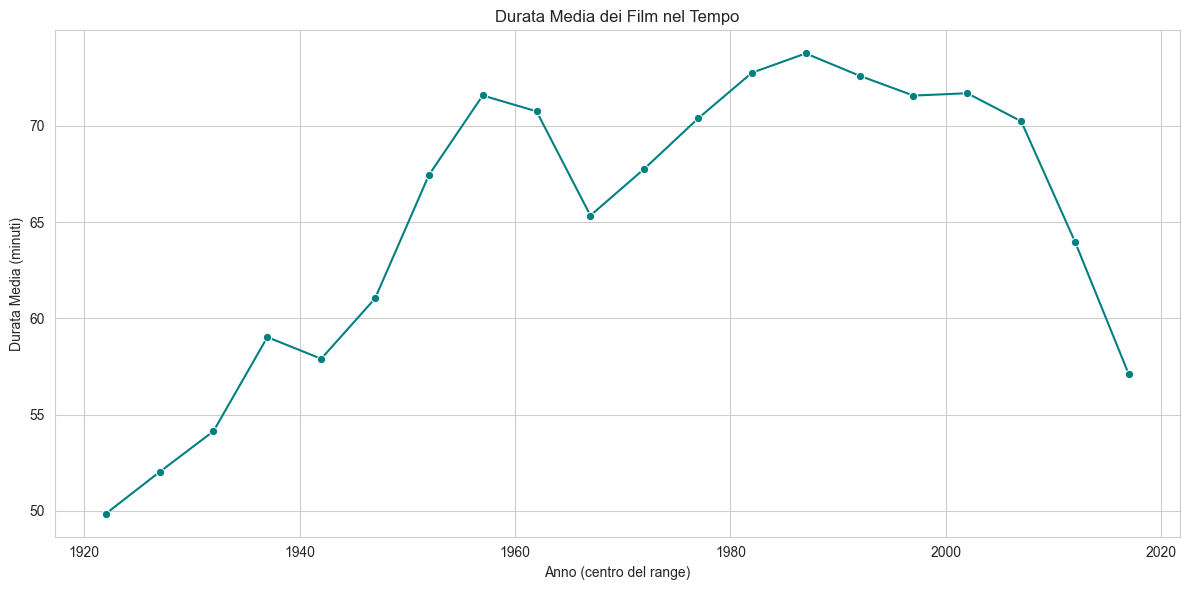

In [ ]:
durata_media_anni = df_released_movies.copy()


bins = list(range(1920, 2025, 5))  # fino al 2020
durata_media_anni['year_bin'] = pd.cut(durata_media_anni['date'], bins=bins, right=False)

durata_media_aggregata = durata_media_anni.groupby('year_bin')['minute'].mean().reset_index()

durata_media_aggregata['year_mid'] = durata_media_aggregata['year_bin'].apply(lambda x: x.left + 2)


plt.figure(figsize=(12, 6))
sns.lineplot(x='year_mid', y='minute', data=durata_media_aggregata, marker='o', color='teal')
plt.title("Durata Media dei Film nel Tempo")
plt.xlabel("Anno (centro del range)")
plt.ylabel("Durata Media (minuti)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

La durata dei film in media dell'anno è aumentata, questo ci può far pensare che questo aumento sia la causa della diminuzione delle valutazioni.

Creiamo uno scatterplot per rappresentare la correlazione tra durata e rating.


/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_28014/3880126931.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



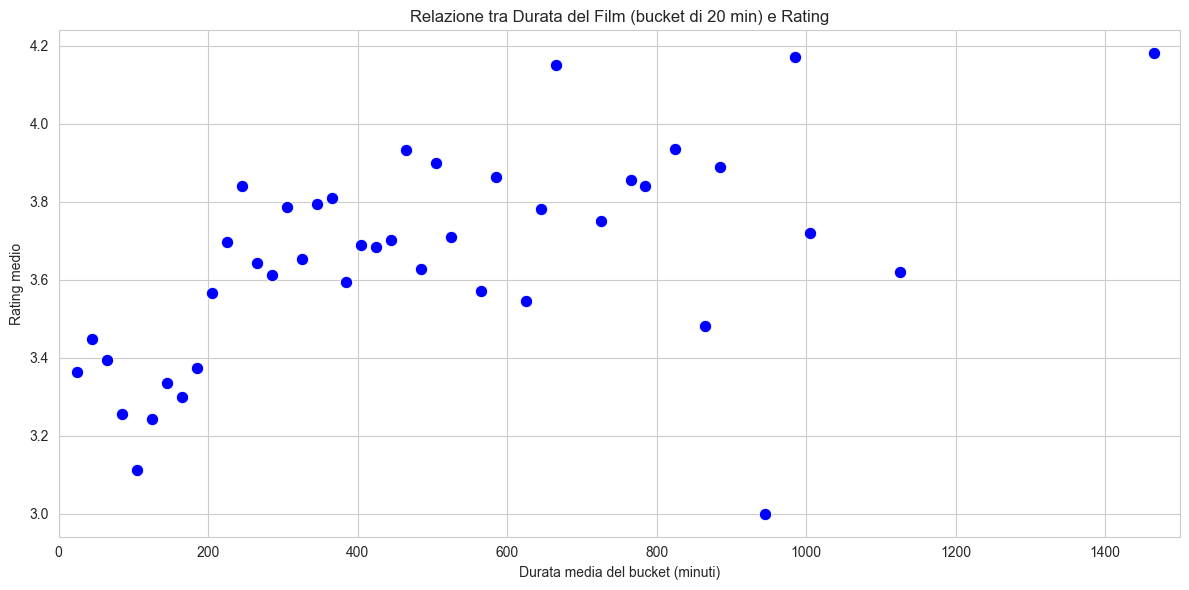

In [ ]:
df_rating_movies = df_released_movies.copy()
df_rating_movies = df_rating_movies[(df_rating_movies['minute'] >= 0) & (df_rating_movies['minute'] <= 2000)]
bins = list(range(0, 1501, 20))  # da 0 a 1450 inclusi
df_rating_movies['minute_bin'] = pd.cut(df_rating_movies['minute'], bins=bins, right=False)

# Calcolo della media del rating per ciascun bucket
agg_rating = df_rating_movies.groupby('minute_bin')['rating'].mean().reset_index()

# Calcolo punto centrale di ogni bucket per il plot
agg_rating['minute_mid'] = agg_rating['minute_bin'].apply(lambda x: x.left + 25)

# Plot
plt.figure(figsize=(12, 6))
sns.scatterplot(x='minute_mid', y='rating', data=agg_rating, color='blue', s=80)
plt.xlim(0, 1500)
plt.title("Relazione tra Durata del Film (bucket di 20 min) e Rating")
plt.xlabel("Durata media del bucket (minuti)")
plt.ylabel("Rating medio")
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

Vediamo che la correlazione è presente in minima parte, possiamo dedurre quindi che le persone si affezionano ai personaggi su film che durano di più?


### Risultato analisi:

Uno dei fattori più evidenti che abbiamo analizzato è che il numero di film prodotti è aumentato notevolmente nel tempo. Questo porta a diversi effetti:

Diminuzione della qualità media: Con l'aumento del numero di film, è più probabile che vengano prodotti molti film di qualità inferiore, riducendo il rating medio complessivo.
Sovraccarico del pubblico: Con troppi film disponibili, gli spettatori possono diventare più esigenti e difficilmente daranno buone valutazioni.
Produzione industrializzata: La crescente commercializzazione e standardizzazione di molti film può portare a sceneggiature meno originali,con storie ripetute molte volte,abbassando la percezione della qualità.

Sicuramente il cambiamento del gusto del pubblico,infatti possiamo notare che ci sono generi che hanno un valore molto maggiore in alcune fasce annuali, come il Drama negli anni del dopoguerra e i generi Music negli anni più recenti.
Infine quasi sicuramente l'accessibilità alle recensioni è aumentata, causando quindi il voto del pubblico di essere maggiore con il tempo con l'avvento delle critiche online.


---


## Analisi degli Oscar dei paesi produttori di film

- Vi sono paesi che hanno prodotto più film di alto successo ? Se si, di conseguenza quei paesi avranno vinto più Oscar con film prodotti dal loro?
- Gli studios di Hollywood e la cinematografia francese, rispecchiano le aspettative e la nomea che si portano dietro in vincite di Oscars?
- È presente un genere di film che si discosta particolarmente rispetto agli altri per il numero di Oscar vinti?


In [129]:
successful_movies_countries= df_movies.merge(df_countries,left_on="id",right_on="id_film", how="left")
successful_movies_per_country = (
    successful_movies_countries.groupby('country')['id'].count().reset_index().rename(columns={'id': 'successful_movies_count'})
)
successful_movies_per_country = successful_movies_per_country.sort_values(
    by='successful_movies_count', ascending=False
)

top_10 = successful_movies_per_country.head(10)


Notiamo quindi che gli Stati Uniti sono il paese con il maggior numero di film di successo, seguito da Regno Unito e Francia.
Possiamo aspettarci quindi che grafico degli oscar vinti per paese possa rispecchiare questo risultato, avendo l'America un numero maggiore di film di successo.
Calcoliamo quanti oscar sono stati vinti dai paesi produttori di film.


In [130]:
df_oscars["year_film"] = pd.to_numeric(df_oscars["year_film"], errors="coerce").astype("Int64")
df_oscars["year_ceremony"] = pd.to_numeric(df_oscars["year_ceremony"], errors="coerce").astype("Int64")

In [131]:
oscars_winners = df_oscars[df_oscars["winner"] == True]
oscars_winners = oscars_winners.merge(df_movies, left_on="film", right_on="name", how="left")
oscars_winners = oscars_winners.merge(df_countries, left_on="id", right_on="id_film", how="left")
oscar_per_country = oscars_winners.groupby("country").size().reset_index(name="oscar_count")

oscar_top_10 = top_10.merge(oscar_per_country, on="country", how="left").fillna(0)
oscar_top_10 = oscar_top_10.sort_values(by="oscar_count", ascending=False)

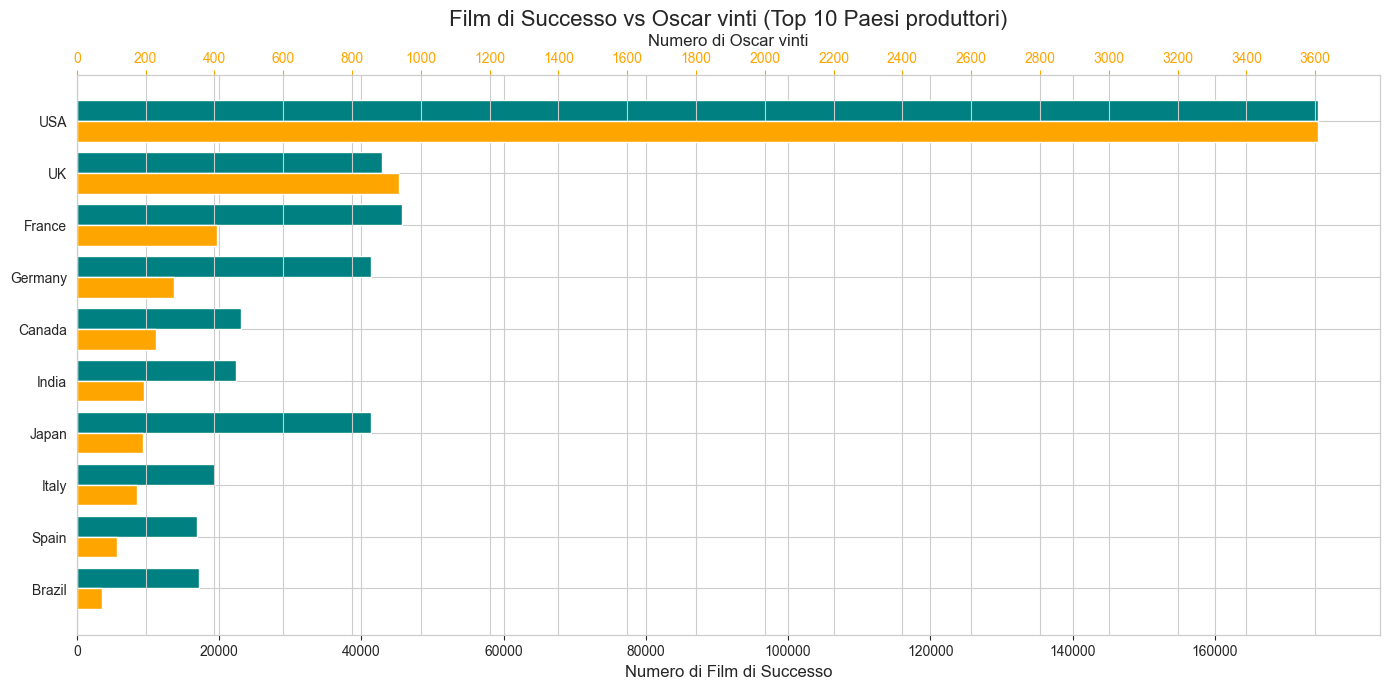

In [141]:
fig, ax1 = plt.subplots(figsize=(14, 7))
sns.set_style("whitegrid")

countries = oscar_top_10['country']
x = np.arange(len(countries))
width = 0.4

ax1.barh(x - width/2, oscar_top_10['successful_movies_count'], height=width, label='Film di successo', color='teal')
ax1.set_xlabel("Numero di Film di Successo", fontsize=12)
ax1.set_yticks(x)
ax1.set_yticklabels(countries)
ax1.invert_yaxis() 
ax1.tick_params(axis='x')
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax1.set_xticks(np.arange(0, max(oscar_top_10['successful_movies_count']), 20000))
ax2 = ax1.twiny()

ax2.barh(x + width/2, oscar_top_10['oscar_count'], height=width, label='Oscar vinti', color='orange')
ax2.set_xlabel("Numero di Oscar vinti", fontsize=12)
ax2.tick_params(axis='x', colors='orange')
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
ax2.set_xticks(np.arange(0, max(oscar_top_10['oscar_count']), 200))
plt.title("Film di Successo vs Oscar vinti (Top 10 Paesi produttori)", fontsize=16)
fig.tight_layout()
plt.show()


In [19]:
fig = px.choropleth(
    oscar_per_country.reset_index(), 
    locations='country', 
    locationmode='country names', 
    color='oscar_count',
    title="Paesi che hanno vinto più Oscar",
    color_continuous_scale='Viridis'
)
fig.show()

Vediamo chiaramente come l'America abbia un controllo sul numero di Oscar vinti, questo probabilmente dovuto alla supremazia di Hollywood come casa produttrice.
La situazione non cambia nelle prime 3 posizioni, mentre successivamente notiamo che i paesi con più film con oscar vinti variano rispetto ai paesi con film di maggior successo, identificando come questo non sia strettamente legato ai film di successo ma più alla quantità di film prodotti, quindi possiamo dedurre che con più film si hanno più possibilità di ottenere una nominazione qualsiasi agli Oscar.


# Hollywood e Cinematografia Francese


In [20]:
hollywood_studios = ["warner", "paramount", "sony", "universal", "warner", "20thcenturyfox"]
pattern = '|'.join(hollywood_studios)

In [21]:
df_hw_studios = df_studios[df_studios["studio"].apply(lambda x: x.lower().replace(" ", "")).str.contains(pattern, na=False, regex=True)].set_index("id_film")

In [22]:
df_movies_filtered = df_released_movies.copy()
df_movies_filtered = df_movies_filtered[(df_movies_filtered['date'] >= 1920) & (df_movies_filtered['date'] <= 2020)]
df_hw_movies = df_movies_filtered[df_movies_filtered.set_index('id').index.isin(df_hw_studios.index)]
df_not_hw_movies = df_movies_filtered[~df_movies_filtered.set_index('id').index.isin(df_hw_studios.index)]

In [23]:
df_hw_movies['year_bin'] = (df_hw_movies['date'] // 5) * 5
df_not_hw_movies['year_bin'] = (df_not_hw_movies['date'] // 5) * 5

df_rating_plot_hw = df_hw_movies.groupby('year_bin')['rating'].mean().reset_index()


/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_28014/2335721102.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_28014/2335721102.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [24]:
df_french_movies = pd.merge(left=df_movies_filtered, right=df_countries, left_on='id', right_on='id_film', how="inner")
df_french_movies = df_french_movies[df_french_movies['country'] == 'France']
df_not_french_movies = df_movies_filtered[~df_movies_filtered.index.isin(df_french_movies.index)]

/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_28014/121541256.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



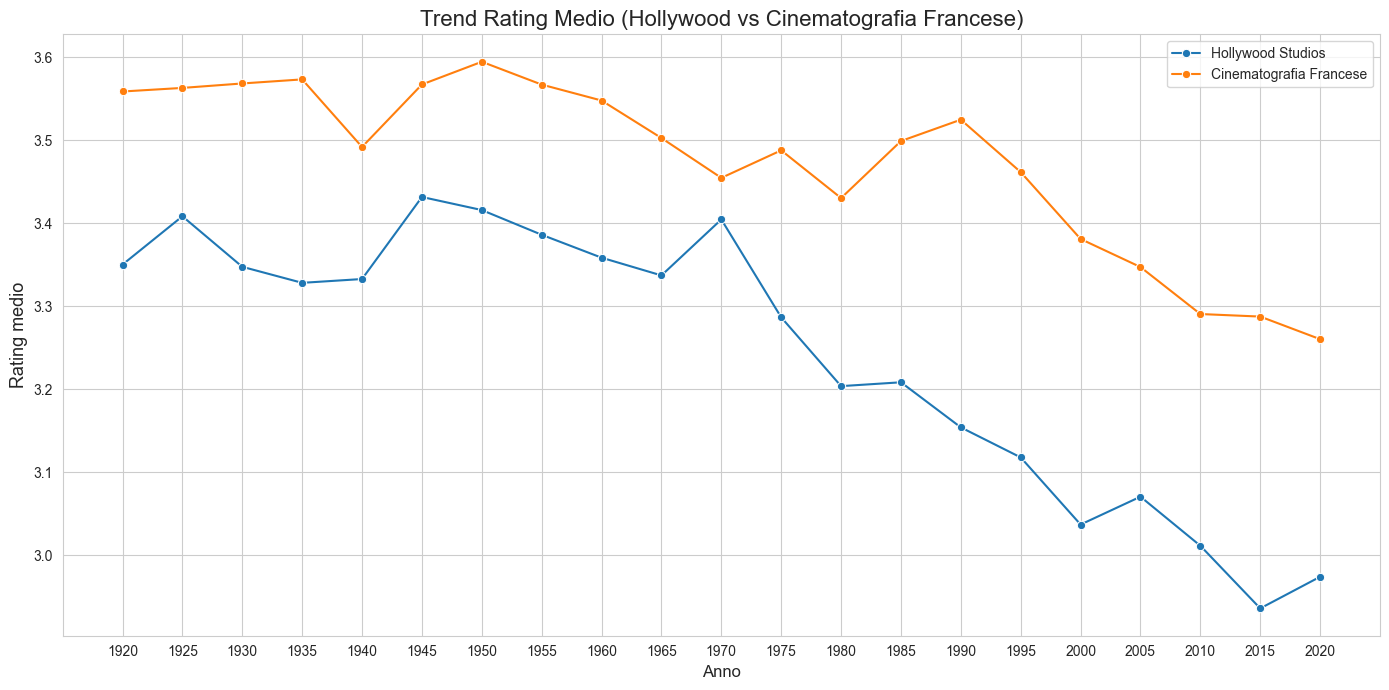

In [ ]:
df_hw_movies['year_bin'] = (df_hw_movies['date'] // 5) * 5
df_french_movies['year_bin'] = (df_french_movies['date'] // 5) * 5

df_rating_plot_hw = df_hw_movies.groupby('year_bin')['rating'].mean().reset_index()
df_rating_plot_french = df_french_movies.groupby('year_bin')['rating'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_rating_plot_hw, x='year_bin', y='rating', label='Hollywood Studios', marker='o')
sns.lineplot(data=df_rating_plot_french, x='year_bin', y='rating', label='Cinematografia Francese', marker='o')
plt.title("Trend Rating Medio (Hollywood vs Cinematografia Francese)", fontsize=16)
plt.xlabel("Anno", fontsize=12)
plt.ylabel("Rating medio", fontsize=13)
plt.gca().set_xticks(np.arange(1920,df_rating_plot_hw["year_bin"].max() + 5, 5))
plt.grid(True, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

# Dopo aver analizzato il rating medio di film dei rinomati Hollywood, della cinematografia francese e aver avuto una visione generale della situazione, poniamo il focus sugli oscar vinti da film francesi e da Hollywood


In [28]:
df_winning = df_oscars[df_oscars['winner'] == True]
df_french_movies = pd.merge(left=df_movies_filtered, right=df_countries, left_on='id', right_on='id_film', how="inner")
df_french_movies = df_french_movies[df_french_movies['country'] == 'France']
df_hw_movies = df_movies_filtered[df_movies_filtered.set_index('id').index.isin(df_hw_studios.index)]

In [29]:
df_winning_hw = pd.merge(left=df_hw_movies, right=df_winning, left_on='name', right_on='film', how='inner')
df_winning_french = pd.merge(left=df_french_movies, right=df_winning, left_on='name', right_on='film', how='inner')
df_winning_hw = df_winning_hw.drop_duplicates(subset=['name_x'])
df_winning_french = df_winning_french.drop_duplicates(subset=['name_x'])

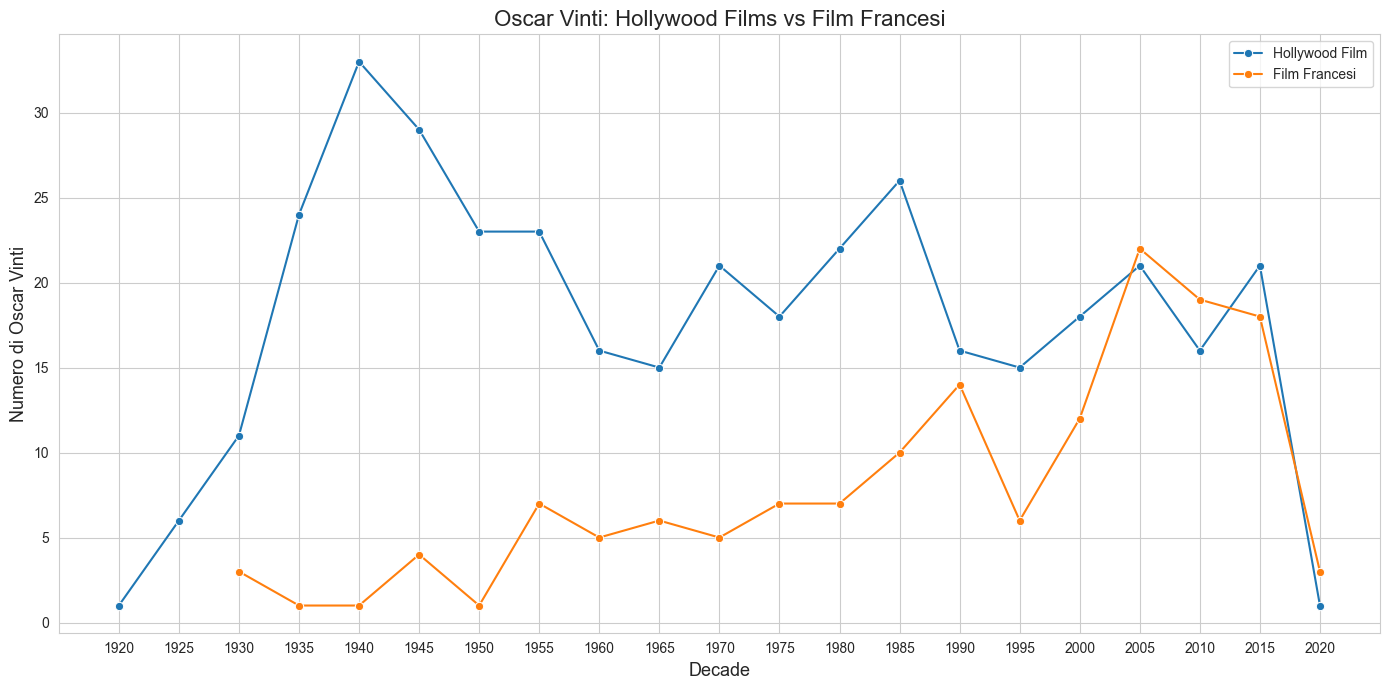

In [ ]:
df_winning_hw['decade'] = (df_winning_hw['date'] // 5) * 5
df_winning_french['decade'] = (df_winning_french['date'] // 5) * 5

hw_decade_counts = df_winning_hw.groupby('decade').size().reset_index(name='count')
french_decade_counts = df_winning_french.groupby('decade').size().reset_index(name='count')

plt.figure(figsize=(14, 7))
sns.lineplot(data=hw_decade_counts, x='decade', y='count', marker='o', label='Hollywood Film')
sns.lineplot(data=french_decade_counts, x='decade', y='count', marker='o', label='Film Francesi')

plt.title("Oscar Vinti: Hollywood Films vs Film Francesi", fontsize=16)
plt.xlabel("Decade", fontsize=13)
plt.ylabel("Numero di Oscar Vinti", fontsize=13)
plt.gca().set_xticks(np.arange(1920, hw_decade_counts["decade"].max() + 5, 5)) # se no 'numpy.float64' object cannot be interpreted as an integer
plt.grid(True, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

Nonostante il rating medio della critica sulla cinematografia francese sia costantemente negli anni più alto dei film prodotty ad Hollywood, notiamo la supremazia negli anni da parte dei film Hollywoodiani.


Abbiamo osservato che i film prodotti dagli studios di Hollywood hanno generalmente vinto un numero di Oscar nettamente inferiore rispetto a quelli realizzati in Francia. Tuttavia, emerge un'interessante eccezione: nel decennio tra il 2000 e il 2010, i film francesi hanno registrato un'impennata nelle vittorie, avvicinandosi (e in alcuni casi superando) i successi hollywoodiani.

Negli anni successivi, però, Hollywood ha rapidamente ristabilito la sua supremazia, confermando la propria leadership storica nella produzione di film premiati, sostenuta da mezzi produttivi più imponenti, distribuzione globale e una forte influenza culturale sull'industria cinematografica mondiale.


# Il genere è correlato alla vincita di Oscars?


Analiziamo i generi premiati di più nella storia cinematografica


In [31]:
df_oscars['film'] = df_oscars['film'].fillna('')
df_released_movies['name'] = df_released_movies['name'].fillna('')

In [32]:
def normalize_title(title):
    return title.lower().strip()

df_oscars['film_norm'] = df_oscars['film'].apply(normalize_title)
df_released_movies['name_norm'] = df_released_movies['name'].apply(normalize_title)

In [33]:
oscars_winners = df_oscars[df_oscars["winner"] == True]

oscars_winners = oscars_winners.merge(df_released_movies, left_on="film_norm", right_on="name_norm", how="inner")

oscars_genres = oscars_winners.merge(df_genres, left_on="id", right_on="id_film", how="left")

oscars_per_genre = (
    oscars_genres.groupby("genre")
    .size()
    .reset_index(name="oscar_wins")
    .sort_values(by="oscar_wins", ascending=False)
)



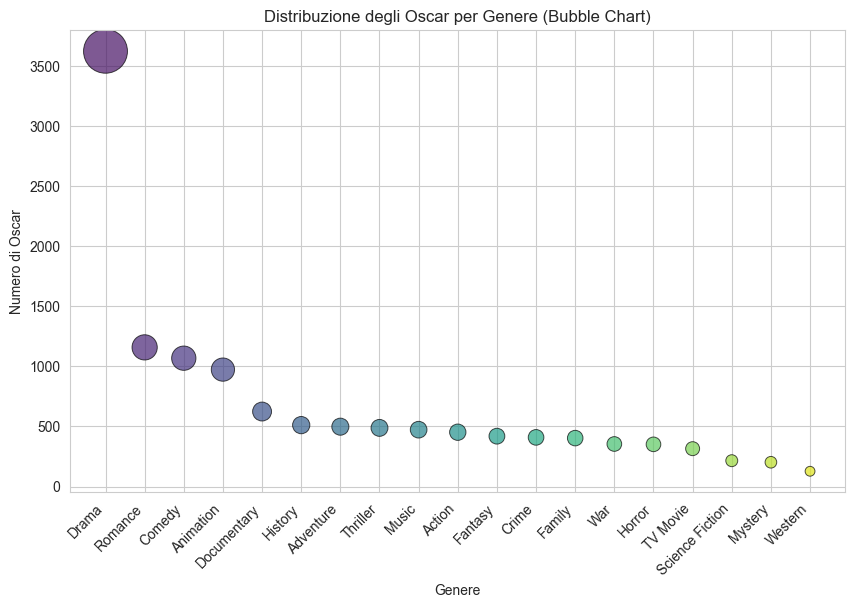

In [ ]:
plt.figure(figsize=(10, 6))
scatter=sns.scatterplot(
    x=range(len(oscars_per_genre)), 
    y=oscars_per_genre["oscar_wins"], 
    size=oscars_per_genre["oscar_wins"], 
    sizes=(50, 1000),  # dimensione delle bolle
    hue=oscars_per_genre["genre"], 
    palette="viridis", 
    edgecolor="black", 
    alpha=0.7,
    legend=False
)
plt.xticks(range(len(oscars_per_genre)), oscars_per_genre["genre"], rotation=45, ha="right")
plt.xlabel("Genere")
plt.ylabel("Numero di Oscar")
plt.title("Distribuzione degli Oscar per Genere (Bubble Chart)")
plt.show()

Non è solo la qualità o la quantità dei film a influenzare il successo agli Oscar.
È anche una questione di scelta strategica dei generi.
In particolare, il Drama è nettamente favorito.


In [35]:
drama_genres = df_genres[df_genres['genre'] == 'Drama']
drama_films = pd.merge(left=drama_genres, right=df_released_movies, left_on='id_film', right_on='id', how='inner')

In [36]:
drama_with_country = pd.merge(drama_films, df_countries, left_on='id', right_on='id_film')

In [37]:
drama_with_top_10 = drama_with_country[drama_with_country['country'].isin(top_10['country'])]
drama_count_top10 = drama_with_top_10['country'].value_counts()

In [38]:
total_films_per_country = df_countries['country'].value_counts()
total_films_top10 = total_films_per_country.loc[top_10['country']]

In [39]:
drama_percentage_top10 = (drama_count_top10 / total_films_top10) * 100
drama_percentage_top10

country
Brazil     24.099465
Canada     26.316474
France     30.532531
Germany    33.420448
India      48.381191
Italy      32.115395
Japan      25.209129
Spain      32.935943
UK         26.389989
USA        25.235975
Name: count, dtype: float64

/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_28014/3165302411.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




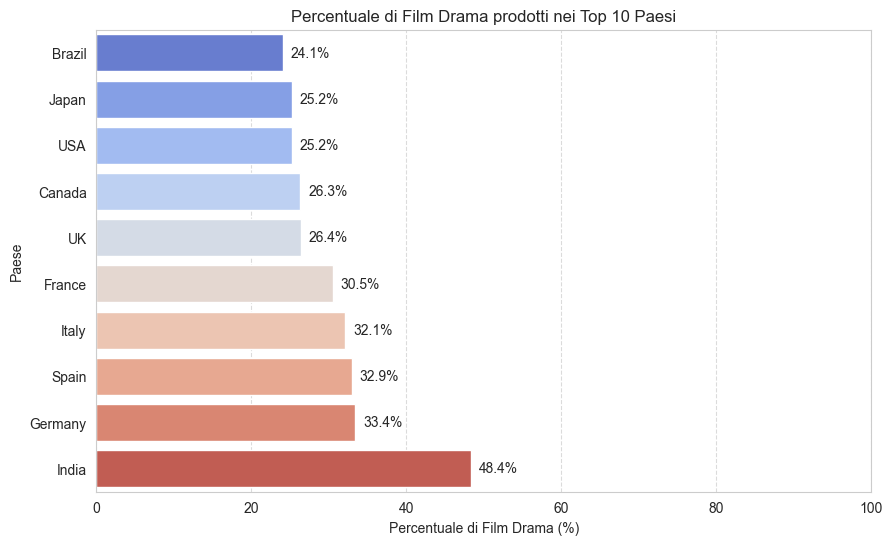

In [40]:
drama_percentage_top10 = drama_percentage_top10.sort_values(ascending=True)  # ascendente per barh

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x=drama_percentage_top10, 
    y=drama_percentage_top10.index, 
    palette="coolwarm"
)

for index, value in enumerate(drama_percentage_top10):
    plt.text(value + 1, index, f"{value:.1f}%", va='center')

plt.xlabel('Percentuale di Film Drama (%)')
plt.ylabel('Paese')
plt.title('Percentuale di Film Drama prodotti nei Top 10 Paesi')
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Risultato della analisi:

Possiamo affermare che l'America è il paese che ha prodotto film di maggiore successo all'interno nella storia, vincendo anche la maggior parte degli Oscar nei film prodotti nel paese, specificatamente grazie ai film prodotti ad Hollywood.

Abbiamo poi condotto un confronto tra due storici colossi della cinematografia, quella francese e la Hollywoodiana, traendo alcune conclusioni:

- Hollywood storicamente ha sempre vinto più oscars
- La cinematografia francese ha avuto un apprezzamento dalla critica negli anni sempre maggiore ai film prodotti ad Hollywood

La conclusione di questo ramo dell'analisi è finita con la curiosità di scoprire come i generi influenzassero la vittoria di un Oscar. Il drama domina le classifiche di Oscar vinti.


## Come i temi dei film sono cambiati nel tempo

- Alcuni temi sono più presenti in certi paesi rispetto ad altri?
- I film storici sono più frequenti in Europa? I film d’azione dominano negli USA?
- I film di fantascienza sono aumentati in Asia negli ultimi decenni?


Partiremo con una analisi di quali temi sono stati i prevalenti durante i vari anni


In [162]:
df_released_cl_data = df_released_movies.copy()
df_released_cl_data = df_released_cl_data.dropna(subset=["date"])[["id", "date", "rating", "name"]]
df_released_cl_data = df_released_cl_data.dropna(subset=["rating", "date"])
df_released_cl_data["date"] = df_released_cl_data["date"].astype(int)
df_released_cl_data = df_released_cl_data[(1920<df_released_cl_data["date"])&(df_released_cl_data["date"]<2020)]

{'whiskers': [<matplotlib.lines.Line2D at 0x301b4a300>,
 'caps': [<matplotlib.lines.Line2D at 0x301b495b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x301b49100>],
 'medians': [<matplotlib.lines.Line2D at 0x301b4ab70>],
 'fliers': [<matplotlib.lines.Line2D at 0x301b4bb60>],
 'means': []}

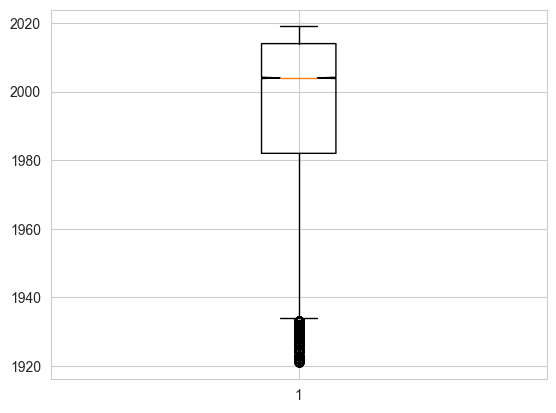

In [163]:
plt.boxplot(df_released_cl_data["date"], df_released_cl_data.groupby("date")["rating"].count().tolist())

In [164]:
data_film_count = df_released_cl_data.groupby("date")["rating"].count()

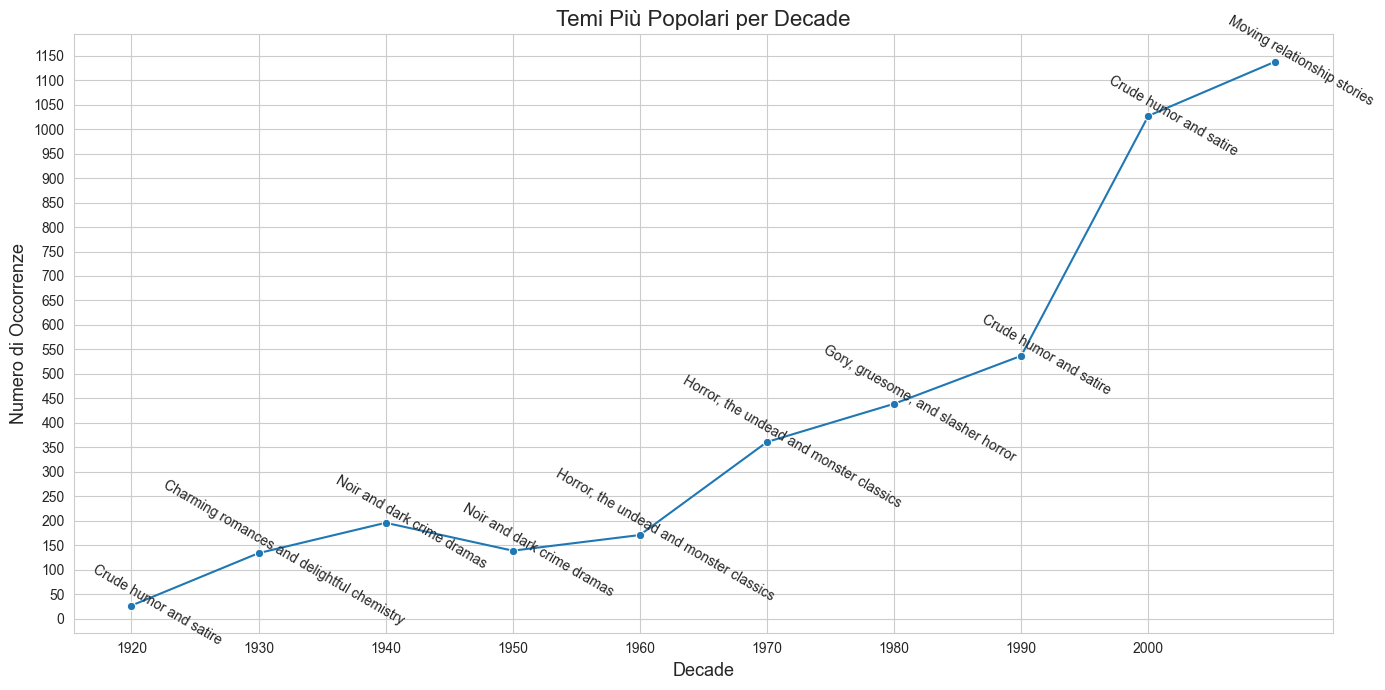

In [ ]:
merged_themes = df_themes.merge(df_released_cl_data, how="inner", left_on="id_film", right_on="id")
merged_themes["date_bin"] = (merged_themes["date"] // 10) * 10

df_date_theme = merged_themes[["date_bin", "theme"]].groupby("date_bin").value_counts().to_frame()

idx = df_date_theme.groupby(level=0)["count"].idxmax()
df_date_hot_theme = df_date_theme.loc[idx].reset_index()

plt.figure(figsize=(14, 7))

sns.lineplot(data=df_date_hot_theme, x='date_bin', y='count', marker='o')

for i, txt in enumerate(df_date_hot_theme["theme"]):
    plt.text(
        df_date_hot_theme["date_bin"].iloc[i] + 2,
        df_date_hot_theme["count"].iloc[i] + 0.5,
        txt,
        fontsize=10,
        ha="center",
        va="center",  # Eliminates built-in text padding
        rotation=-30
    )

plt.title("Temi Più Popolari per Decade", fontsize=16)
plt.xlabel("Decade", fontsize=13)
plt.ylabel("Numero di Occorrenze", fontsize=13)
plt.gca().set_yticks(np.arange(0, df_date_hot_theme["count"].max() + 50, 50))
plt.gca().set_xticks(np.arange(df_date_hot_theme["date_bin"].min(), df_date_hot_theme["date_bin"].max(), 10))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



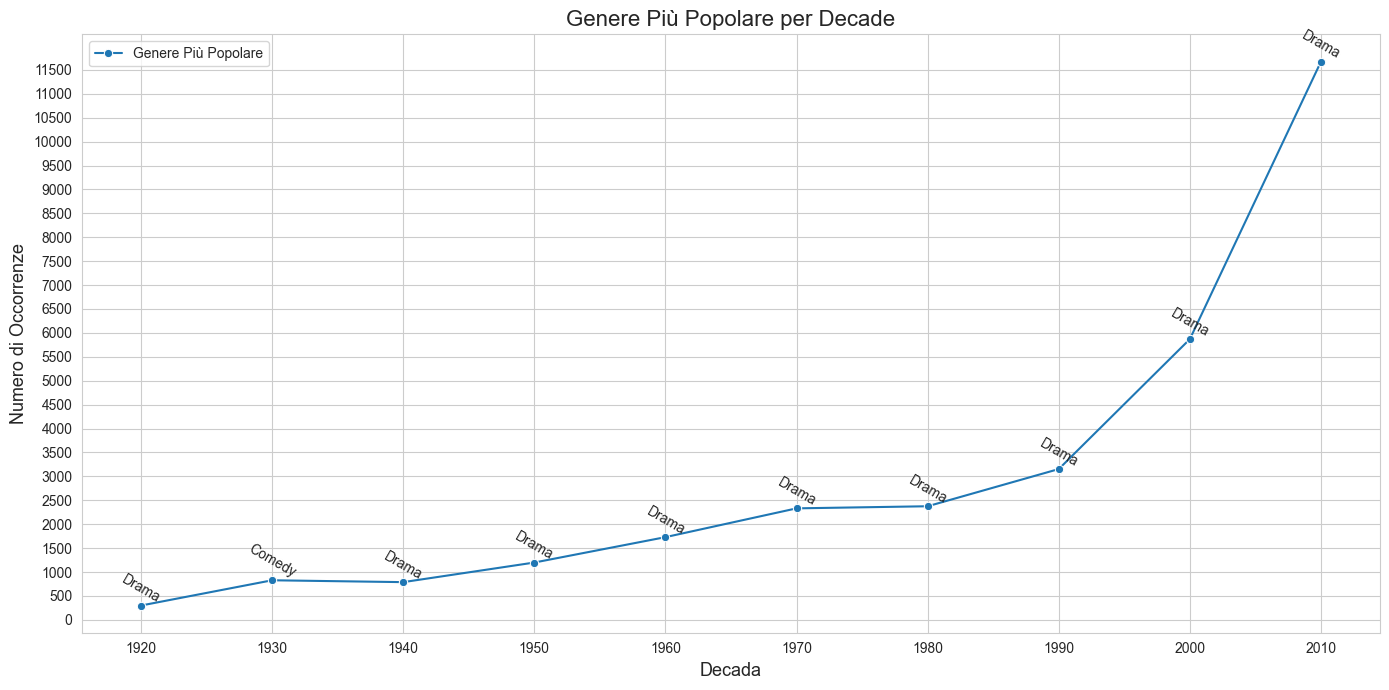

In [ ]:
merged_genre = df_genres.merge(df_released_cl_data, how="inner", left_on="id_film", right_on="id")
merged_genre["date_bin"] = (merged_genre["date"] // 10) * 10

df_date_genre = merged_genre[["date_bin", "genre"]].groupby("date_bin").value_counts().to_frame()

idx = df_date_genre.groupby(level=0)["count"].idxmax()
df_date_hot_genre = df_date_genre.loc[idx].reset_index()

plt.figure(figsize=(14, 7))

sns.lineplot(data=df_date_hot_genre, x='date_bin', y='count', marker='o', label='Genere Più Popolare')

for i, txt in enumerate(df_date_hot_genre["genre"]):
    plt.text(df_date_hot_genre["date_bin"].iloc[i], df_date_hot_genre["count"].iloc[i], txt,
             fontsize=10, ha="center", va="bottom", rotation=-30)

plt.title("Genere Più Popolare per Decade", fontsize=16)
plt.xlabel("Decada", fontsize=13)
plt.ylabel("Numero di Occorrenze", fontsize=13)
plt.gca().set_yticks(np.arange(0, df_date_hot_genre["count"].max() + 100, 500))
plt.gca().set_xticks(np.arange(df_date_hot_genre["date_bin"].min(), df_date_hot_genre["date_bin"].max()+10, 10))

plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

In [46]:
genre_rating = merged_genre[["date_bin", "genre", "rating"]].groupby(["date_bin", "genre"]).agg(['mean', 'count'])["rating"].reset_index()
rating_per_year = merged_genre[["date_bin", "rating"]].groupby(["date_bin"]).count().reset_index().set_index("date_bin")

In [47]:
rating_per_year_dict = rating_per_year.to_dict()
rating_per_year_dict

{'rating': {1910: 596,
  1920: 1243,
  1930: 3938,
  1940: 4576,
  1950: 5633,
  1960: 7804,
  1970: 10878,
  1980: 13738,
  1990: 16802,
  2000: 29552,
  2010: 56717}}

In [48]:
genre_rating["mean_count"] = genre_rating["mean"] * genre_rating["count"]

In [49]:
genre_rating["w_avg"] = genre_rating.apply(lambda x: x["mean_count"]/rating_per_year["rating"][x["date_bin"]], axis=1)

In [50]:
df_highest_genre = genre_rating.loc[genre_rating.groupby("date_bin")["w_avg"].idxmax()].reset_index(drop=True)

In [51]:
genre_rating_dropped = merged_genre[["date_bin", "genre", "rating"]].groupby(["date_bin", "genre"]).mean().dropna(subset=["rating"])

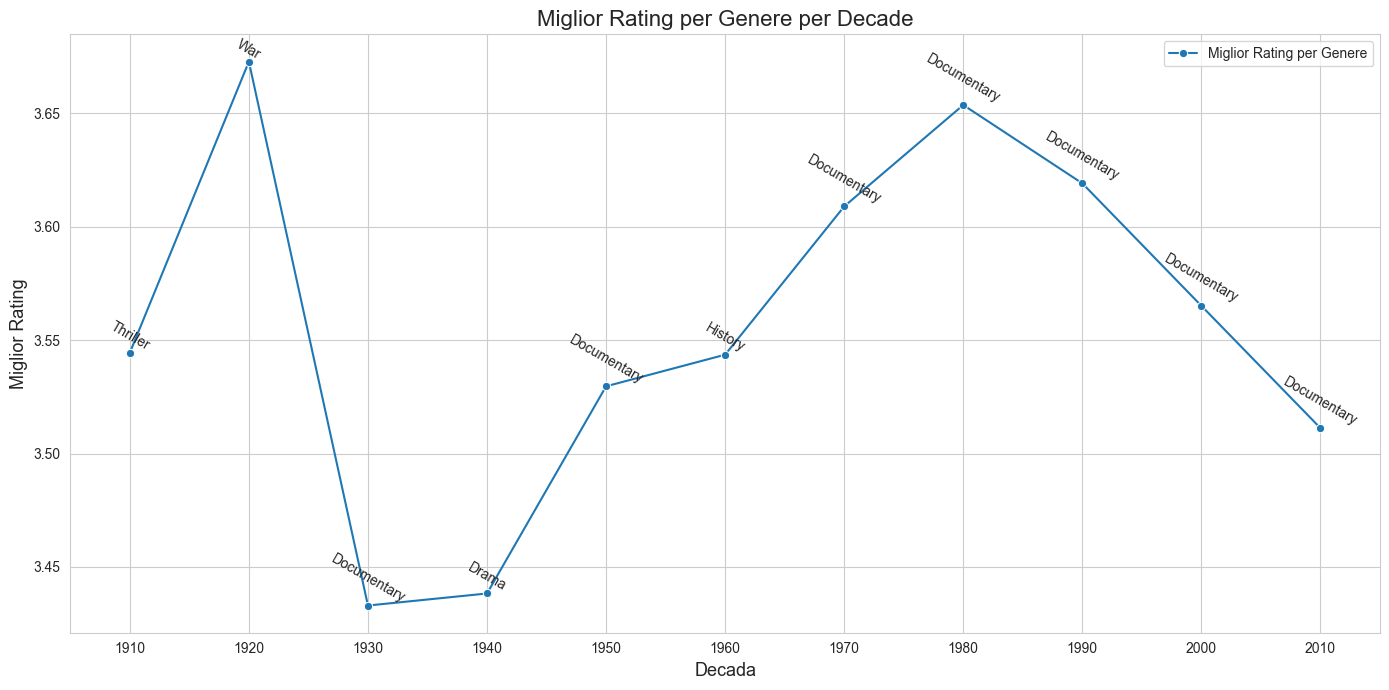

In [ ]:
idx = genre_rating_dropped.groupby(level=0)["rating"].idxmax()
df_date_best_genre = genre_rating_dropped.loc[idx].reset_index()

plt.figure(figsize=(14, 7))

sns.lineplot(data=df_date_best_genre, x='date_bin', y='rating', marker='o', label='Miglior Rating per Genere')

for i, txt in enumerate(df_date_best_genre["genre"]):
    plt.text(df_date_best_genre["date_bin"].iloc[i], df_date_best_genre["rating"].iloc[i], txt,
             fontsize=10, ha="center", va="bottom", rotation=-30)

plt.title("Miglior Rating per Genere per Decade", fontsize=16)
plt.xlabel("Decada", fontsize=13)
plt.ylabel("Miglior Rating", fontsize=13)
plt.gca().set_xticks(np.arange(df_date_best_genre["date_bin"].min(), df_date_best_genre["date_bin"].max()+10, 10))


plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

Avendo ora una idea del comportamento dei temi durante gli anni, possiamo ora analizzarne i comportamenti geograficamente.


In [210]:
themes_romance = ["Moving relationship stories",
"Quirky and endearing relationships",
"Laugh-out-loud relationship entanglements",
"Captivating relationships and charming romance",
"Charming romances and delightful chemistry",
"Emotional LGBTQ relationships",
"Passion and romance",
"Relationship comedy",
"Emotional teen coming-of-age stories",
"Teen friendship and coming-of-age",
"Holiday joy and heartwarming Christmas"]

In [211]:
themes_war_cruelty = [
    'Intense violence and sexual transgression', 'Twisted dark psychological thriller',
    'Intense political and terrorist thrillers', 'Graphic violence and brutal revenge',
    'Crime, drugs and gangsters', 'Gripping, intense violent crime',
    'Gritty crime and ruthless gangsters', 'Violent action, guns, and crime',
    'Brutal, violent prison drama', 'Thrillers and murder mysteries',
    'Explosive and action-packed heroes vs. villains', 'Noir and dark crime dramas',
    'Intriguing and suspenseful murder mysteries', 'War and historical adventure',
    'Nazis and World War II', 'Military combat and heroic soldiers',
    'Bravery in War', 'Intense combat and martial arts',
    'Violent crime and drugs', 'Extreme gory horror and cannibalism',
    'Survival horror and zombie carnage'
]

In [212]:
releases = df_releases.merge(df_countries, left_on="id_film", right_on="id_film", how="left")

In [213]:
themes_geo = releases.merge(df_themes, on="id_film", how="inner")[["country_y", "theme"]]
themes_geo.columns = ["Country", "Theme"]

In [214]:
theme_counts = themes_geo.groupby(["Country", "Theme"]).size().reset_index(name="Count")
total_movies_per_country = theme_counts.groupby("Country")["Count"].sum().reset_index()
total_movies_per_country.columns = ["Country", "Total_Movies"]
theme_counts = theme_counts.merge(total_movies_per_country, on="Country")

theme_counts["Percentage"] = (theme_counts["Count"] / theme_counts["Total_Movies"]) * 100
theme_counts

,Country,Theme,Count,Total_Movies,Percentage
0,Afghanistan,Disastrous voyages and heroic survival,3,65,4.615385
1,Afghanistan,Emotional and touching family dramas,7,65,10.769231
2,Afghanistan,Epic adventure and breathtaking battles,3,65,4.615385
3,Afghanistan,Heartbreaking and moving family drama,7,65,10.769231
4,Afghanistan,Historical battles and epic heroism,1,65,1.538462
...,...,...,...,...,...
5898,Zambia,Thought-provoking sci-fi action and future tec...,1,2,50.000000
5899,Zimbabwe,"Gripping, intense violent crime",30,120,25.000000
5900,Zimbabwe,Heartbreaking and moving family drama,30,120,25.000000
5901,Zimbabwe,Politics and human rights,30,120,25.000000


In [ ]:
# !!! AI GENERATED !!!
continent_mapping = {
    'UK': 'Europe',
    'USA': 'North America',
    'South Korea': 'Asia',
    'Germany': 'Europe',
    'Hong Kong': 'Asia',
    'Canada': 'North America',
    'Sweden': 'Europe',
    'Ireland': 'Europe',
    'Japan': 'Asia',
    'China': 'Asia',
    'France': 'Europe',
    'Brazil': 'South America',
    'Italy': 'Europe',
    'Czechia': 'Europe',
    'New Zealand': 'Oceania',
    'Australia': 'Oceania',
    'India': 'Asia',
    'Spain': 'Europe',
    'Austria': 'Europe',
    'Greece': 'Europe',
    'Netherlands': 'Europe',
    'Poland': 'Europe',
    'Taiwan': 'Asia',
    'Denmark': 'Europe',
    'Norway': 'Europe',
    'Mexico': 'North America',
    'Switzerland': 'Europe',
    'Turkey': 'Asia',
    'Finland': 'Europe',
    'USSR': 'Europe',
    'Singapore': 'Asia',
    'Chile': 'South America',
    'Belgium': 'Europe',
    'United Arab Emirates': 'Asia',
    'Malta': 'Europe',
    'Hungary': 'Europe',
    'South Africa': 'Africa',
    'Bulgaria': 'Europe',
    'Czechoslovakia': 'Europe',
    'Argentina': 'South America',
    'Iceland': 'Europe',
    'Indonesia': 'Asia',
    'Slovenia': 'Europe',
    'Iran': 'Asia',
    'Luxembourg': 'Europe',
    'Philippines': 'Asia',
    'Russian Federation': 'Europe',
    'Malaysia': 'Asia',
    'Portugal': 'Europe',
    'Serbia': 'Europe',
    'Algeria': 'Africa',
    'Estonia': 'Europe',
    'Romania': 'Europe',
    'Colombia': 'South America',
    'Thailand': 'Asia',
    'Cyprus': 'Asia',
    'Lebanon': 'Asia',
    'Qatar': 'Asia',
    'Peru': 'South America',
    'Cambodia': 'Asia',
    'Bahamas': 'North America',
    'Israel': 'Asia',
    'Puerto Rico': 'North America',
    'Cuba': 'North America',
    'Senegal': 'Africa',
    'Bosnia and Herzegovina': 'Europe',
    'Georgia': 'Asia',
    'Guadeloupe': 'North America',
    'Uruguay': 'South America',
    'Pakistan': 'Asia',
    'Sri Lanka': 'Asia',
    'Latvia': 'Europe',
    'Tunisia': 'Africa',
    'Dominican Republic': 'North America',
    'Yugoslavia': 'Europe',
    'Bolivarian Republic of Venezuela': 'South America',
    'Montenegro': 'Europe',
    'Egypt': 'Africa',
    'Ethiopia': 'Africa',
    'Ghana': 'Africa',
    'Jordan': 'Asia',
    'Namibia': 'Africa',
    'Saudi Arabia': 'Asia',
    'Angola': 'Africa',
    'Mali': 'Africa',
    'Myanmar': 'Asia',
    'Morocco': 'Africa',
    'Syrian Arab Republic': 'Asia',
    'Uganda': 'Africa',
    'North Macedonia': 'Europe',
    'Lithuania': 'Europe',
    'Croatia': 'Europe',
    'Slovakia': 'Europe',
    'Malawi': 'Africa',
    'Guatemala': 'North America',
    'Kenya': 'Africa',
    'French Polynesia': 'Oceania',
    'Faroe Islands': 'Europe',
    'Ukraine': 'Europe',
    'Cameroon': 'Africa',
    'Mongolia': 'Asia',
    'Nicaragua': 'North America',
    'Vietnam': 'Asia',
    'Botswana': 'Africa',
    'Rwanda': 'Africa',
    'Zambia': 'Africa',
    'Jamaica': 'North America',
    'Albania': 'Europe',
    'Iraq': 'Asia',
    'Lesotho': 'Africa',
    'Bhutan': 'Asia',
    'State of Palestine': 'Asia',
    'Uzbekistan': 'Asia',
    'North Korea': 'Asia',
    'Burkina Faso': 'Africa',
    'Bermuda': 'North America',
    'Ecuador': 'South America',
    'Netherlands Antilles': 'North America',
    'East Germany': 'Europe',
    'Mauritania': 'Africa',
    'Congo': 'Africa',
    'Monaco': 'Europe',
    'Kuwait': 'Asia',
    'Libya': 'Africa',
    'Ivory Coast': 'Africa',
    'Kazakhstan': 'Asia',
    'Kosovo': 'Europe',
    'Nigeria': 'Africa',
    'Belarus': 'Europe',
    'Zimbabwe': 'Africa',
    'Costa Rica': 'North America',
    'Afghanistan': 'Asia',
    'Aruba': 'North America',
    'Bolivia': 'South America',
    'Democratic Republic of Congo': 'Africa',
    'Panama': 'North America',
    'Greenland': 'North America',
    'Tajikistan': 'Asia',
    'Macao': 'Asia',
    'Sudan': 'Africa',
    'Serbia and Montenegro': 'Europe',
    'Chad': 'Africa',
    "Lao People's Democratic Republic": 'Asia',
    'Bangladesh': 'Asia',
    'Liechtenstein': 'Europe',
    'Paraguay': 'South America',
    'Vanuatu': 'Oceania',
    'Nepal': 'Asia',
    'Palau': 'Oceania',
    'Armenia': 'Asia',
    'Martinique': 'North America',
    'Kyrgyzstan': 'Asia',
    'Réunion': 'Africa',
    'Central African Republic': 'Africa',
    'Haiti': 'North America',
    'Madagascar': 'Africa',
    'Benin': 'Africa',
    'Antarctica': 'Antarctica',
    'Samoa': 'Oceania',
    'Eswatini': 'Africa',
    'United Republic of Tanzania': 'Africa',
    'Niger': 'Africa',
    'Christmas Island': 'Oceania',
    'Guinea-Bissau': 'Africa',
    'Liberia': 'Africa',
    'Guinea': 'Africa',
    'Svalbard and Jan Mayen': 'Europe',
    'Cayman Islands': 'North America',
    'Timor-Leste': 'Asia',
    'Papua New Guinea': 'Oceania',
    'Nauru': 'Oceania',
    'Azerbaijan': 'Asia',
    'Saint Pierre and Miquelon': 'North America',
    'New Caledonia': 'Oceania',
    'San Marino': 'Europe',
    'Yemen': 'Asia',
    'Djibouti': 'Africa',
    'Anguilla': 'North America',
    'South Sudan': 'Africa',
    'Suriname': 'South America',
    'Brunei Darussalam': 'Asia',
    'Antigua and Barbuda': 'North America',
    'Republic of Moldova': 'Europe',
    'Belize': 'North America',
    'El Salvador': 'North America',
    'Solomon Islands': 'Oceania',
    'Fiji': 'Oceania',
    'Cape Verde': 'Africa',
    'Turks and Caicos Islands': 'North America',
    'US Virgin Islands': 'North America',
    'Mauritius': 'Africa',
    'Mozambique': 'Africa',
    'Andorra': 'Europe',
    'Comoros': 'Africa',
    'Barbados': 'North America',
    'Vatican City': 'Europe',
    'Guyana': 'South America',
    'Togo': 'Africa',
    'Honduras': 'North America',
    'Somalia': 'Africa',
    'Gabon': 'Africa',
    'Kiribati': 'Oceania',
    'Bahrain': 'Asia',
    'Burundi': 'Africa',
    'Trinidad and Tobago': 'North America',
    'British Indian Ocean Territory': 'Asia',
    'French Guiana': 'South America',
    'Saint Kitts and Nevis': 'North America',
    'Oman': 'Asia',
    'Tuvalu': 'Oceania',
    'Western Sahara': 'Africa',
    'Tonga': 'Oceania',
    'American Samoa': 'Oceania',
    'Falkland Islands': 'South America',
    'South Georgia and the South Sandwich Islands': 'South America',
    'French Southern Territories': 'Antarctica',
    'Tokelau': 'Oceania',
    'Gibraltar': 'Europe',
    'Grenada': 'North America',
    'Gambia': 'Africa',
    'Turkmenistan': 'Asia',
    'Sao Tome and Principe': 'Africa',
    'British Virgin Islands': 'North America',
    'Sierra Leone': 'Africa',
    'Cocos (Keeling) Islands': 'Asia',
    'Equatorial Guinea': 'Africa',
    'Saint Lucia': 'North America',
    'Federated States of Micronesia': 'Oceania',
    'Dominica': 'North America',
    'Northern Mariana Islands': 'Oceania',
    'Wallis and Futuna': 'Oceania',
    'Niue': 'Oceania',
    'Eritrea': 'Africa',
    'Saint Helena, Ascension and Tristan da Cunha': 'Africa',
    'Saint Vincent and the Grenadines': 'North America',
    'Pitcairn': 'Oceania',
    'Marshall Islands': 'Oceania',
    'Heard Island and McDonald Islands': 'Antarctica',
    'United States Minor Outlying Islands': 'Oceania',
    'Norfolk Island': 'Oceania',
    'Cook Islands': 'Oceania',
    'Montserrat': 'North America',
    'Bouvet Island': 'Antarctica',
    'Seychelles': 'Africa',
    'Maldives': 'Asia',
    'Mayotte': 'Africa',
    'Guam': 'Oceania'
}

In [234]:
df_themes_movies = pd.merge(df_themes, df_released_movies, left_on="id_film", right_on="id", how="inner")
df_themes_country_movies = pd.merge(df_themes_movies, df_countries, left_on="id_film", right_on="id_film", how="inner")

df_themes_country_movies = df_themes_country_movies.drop_duplicates(subset=["id_film", "theme", "country"])
df_romance_country_movies = df_themes_country_movies[(df_themes_country_movies["theme"].isin(themes_romance))]

df_movies_country = pd.merge(df_released_movies, df_countries, left_on='id', right_on="id_film", how="inner")
total_movies_per_country = df_movies_country.groupby('country')['id'].nunique()

df_themes_country_movies['continent'] = df_themes_country_movies['country'].map(continent_mapping)
df_romance_country_movies['continent'] = df_romance_country_movies['country'].map(continent_mapping)
df_movies_country['continent'] = df_movies_country['country'].map(continent_mapping)

df_themes_country_movies.dropna(subset=['continent'], inplace=True)
df_romance_country_movies.dropna(subset=['continent'], inplace=True)
df_movies_country.dropna(subset=['continent'], inplace=True)

total_movies_per_continent = df_movies_country.groupby('continent')['id'].nunique()

romantic_movies_per_continent = df_romance_country_movies.groupby('continent')['id_film'].nunique()

romance_percentage_continent = (romantic_movies_per_continent / total_movies_per_continent) * 100

romance_percentage_continent = romance_percentage_continent.dropna().sort_values(ascending=False)

/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_28014/3427587494.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_28014/3427587494.py:15: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



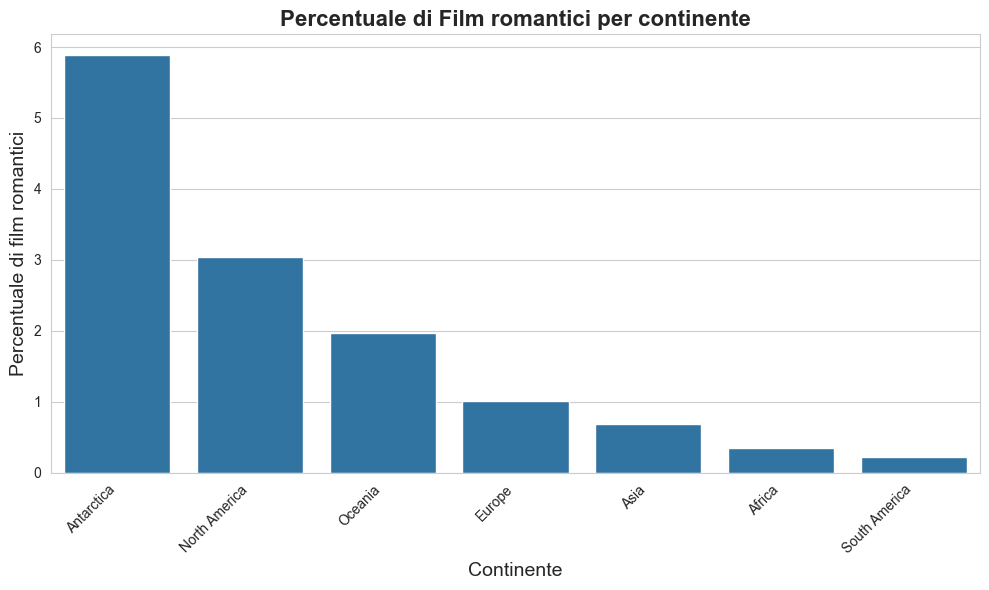

In [260]:
plt.figure(figsize=(10, 6))
sns.barplot(x=romance_percentage_continent.index, y=romance_percentage_continent.values)
plt.title("Percentuale di Film romantici per continente", fontsize=16, fontweight='bold')
plt.xlabel("Continente", fontsize=14)
plt.ylabel("Percentuale di film romantici", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [245]:
df_war_cruelty = df_themes_country_movies[df_themes_country_movies["theme"].isin(themes_war_cruelty)]
war_cruelty_movies_per_country = df_war_cruelty.groupby('country')['id_film'].nunique()

df_war_cruelty['continent'] = df_war_cruelty['country'].map(continent_mapping)
df_war_cruelty.dropna(subset=['continent'], inplace=True)

war_cruelty_movies_per_continent = df_war_cruelty.groupby('continent')['id_film'].nunique()

war_cruelty_percentage_continent = (war_cruelty_movies_per_continent / total_movies_per_continent) * 100

war_cruelty_percentage_continent = war_cruelty_percentage_continent.dropna().sort_values(ascending=False)

/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_28014/2884534221.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_28014/2884534221.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



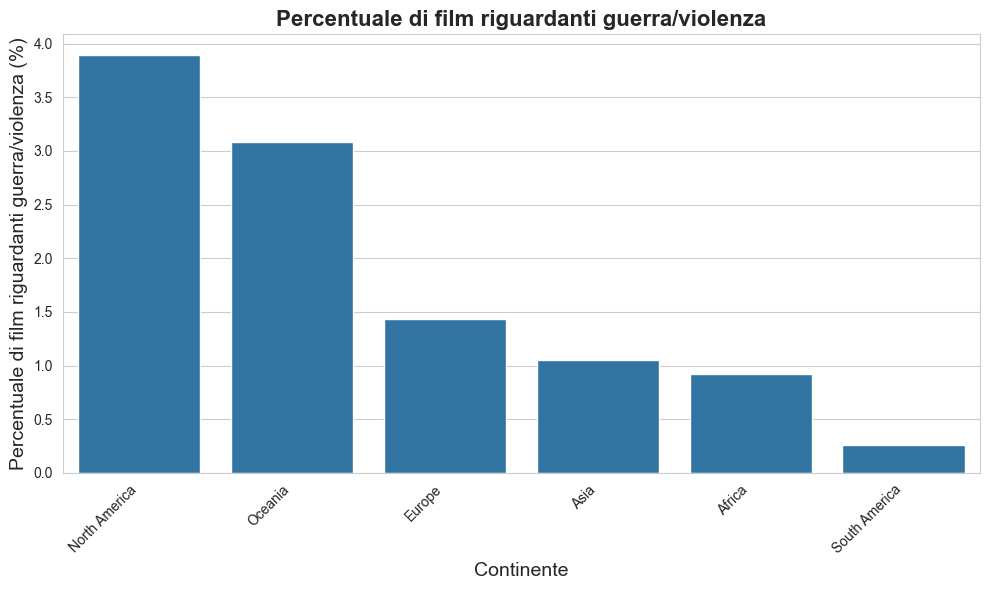

In [261]:
plt.figure(figsize=(10, 6))
sns.barplot(x=war_cruelty_percentage_continent.index, y=war_cruelty_percentage_continent.values)
plt.title("Percentuale di film riguardanti guerra/violenza", fontsize=16, fontweight='bold')
plt.xlabel("Continente", fontsize=14)
plt.ylabel("Percentuale di film riguardanti guerra/violenza (%)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_28014/2928259801.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_28014/2928259801.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



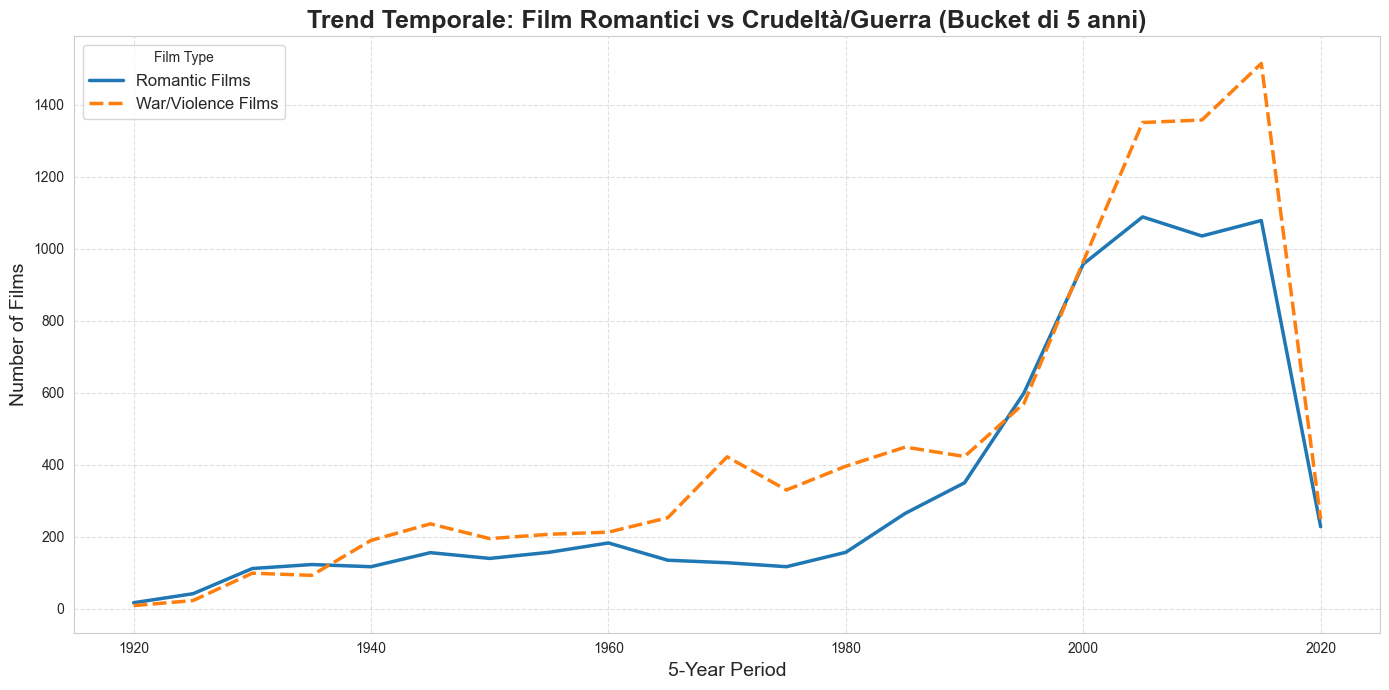

In [262]:
df_movies_filt = df_released_movies[(df_released_movies["date"] >= 1920) & (df_released_movies["date"] <= 2020)]
df_themes_movies = pd.merge(df_themes, df_movies_filt, left_on="id_film", right_on="id", how="inner")

df_romance = df_themes_movies[df_themes_movies["theme"].isin(themes_romance)]
df_war_cruelty = df_themes_movies[df_themes_movies["theme"].isin(themes_war_cruelty)]

def create_5_year_buckets(year):
    return (year // 5) * 5
df_romance['5_year_bucket'] = df_romance['date'].apply(create_5_year_buckets)
df_war_cruelty['5_year_bucket'] = df_war_cruelty['date'].apply(create_5_year_buckets)

romance_yearly_bucket = df_romance.groupby('5_year_bucket')['id_film'].nunique()
war_cruelty_yearly_bucket = df_war_cruelty.groupby('5_year_bucket')['id_film'].nunique()

trend_bucket_df = pd.DataFrame({
    'Romantic Films': romance_yearly_bucket,
    'War/Violence Films': war_cruelty_yearly_bucket
}).fillna(0)

plt.figure(figsize=(14, 7))
sns.lineplot(data=trend_bucket_df, linewidth=2.5)
plt.title('Trend Temporale: Film Romantici vs Crudeltà/Guerra (Bucket di 5 anni)', fontsize=18, fontweight='bold')
plt.xlabel('5-Year Period', fontsize=14)
plt.ylabel('Number of Films', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Film Type', fontsize=12)

plt.tight_layout()
plt.show()

/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_28014/3465709242.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_28014/3465709242.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



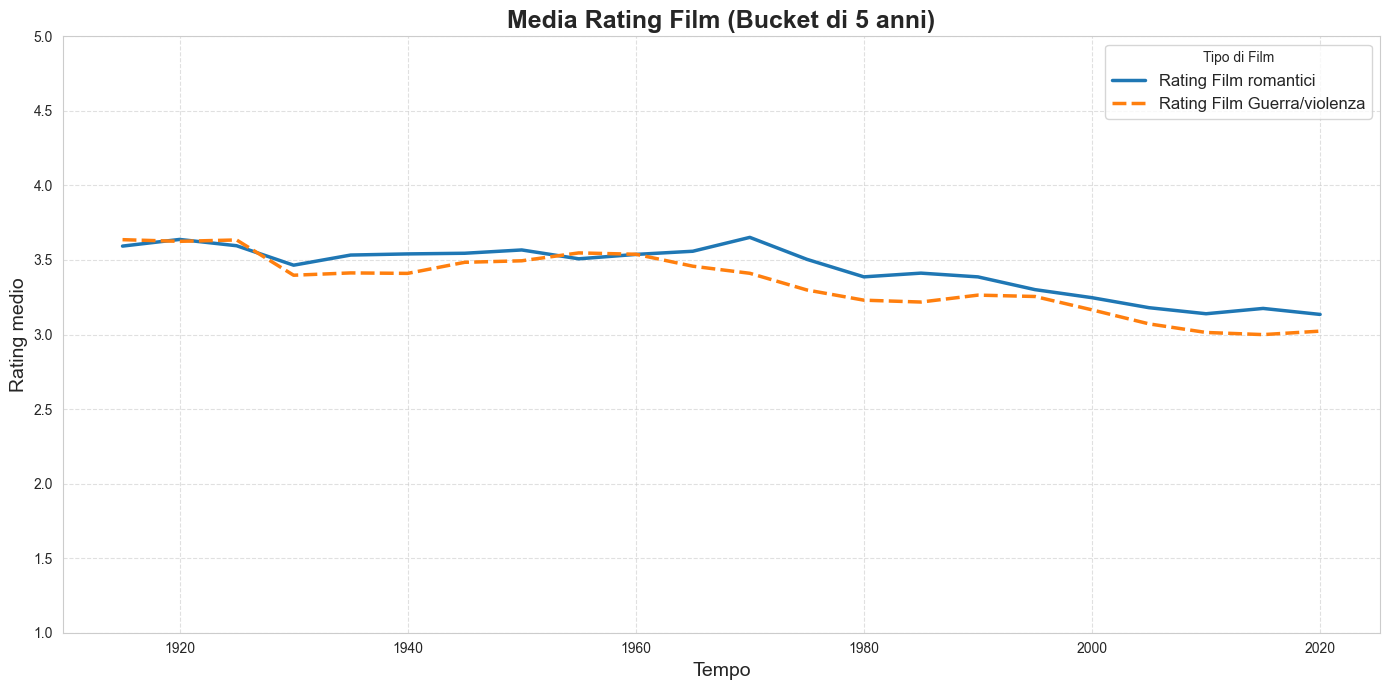

In [263]:
df_themes_movies = pd.merge(df_themes, df_movies, left_on="id_film", right_on="id", how="inner")
df_romance = df_themes_movies[df_themes_movies["theme"].isin(themes_romance)]
df_war_cruelty = df_themes_movies[df_themes_movies["theme"].isin(themes_war_cruelty)]

df_romance['5_year_bucket'] = df_romance['date'].apply(lambda year: (year // 5) * 5)
df_war_cruelty['5_year_bucket'] = df_war_cruelty['date'].apply(lambda year: (year // 5) * 5)

romance_rating_bucket = df_romance.groupby('5_year_bucket')['rating'].mean()
war_cruelty_rating_bucket = df_war_cruelty.groupby('5_year_bucket')['rating'].mean()

rating_trend_bucket_df = pd.DataFrame({
    'Rating Film romantici': romance_rating_bucket,
    'Rating Film Guerra/violenza': war_cruelty_rating_bucket
}).dropna()

plt.figure(figsize=(14, 7))
sns.lineplot(data=rating_trend_bucket_df, linewidth=2.5)
plt.title('Media Rating Film (Bucket di 5 anni)', fontsize=18, fontweight='bold')
plt.xlabel('Tempo', fontsize=14)
plt.ylabel('Rating medio', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Tipo di Film', fontsize=12)

plt.ylim(1, 5)
plt.tight_layout()
plt.show()

/var/folders/sq/qp2ff4vn2g9_6vmpy83jznrh0000gn/T/ipykernel_28014/3127504065.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



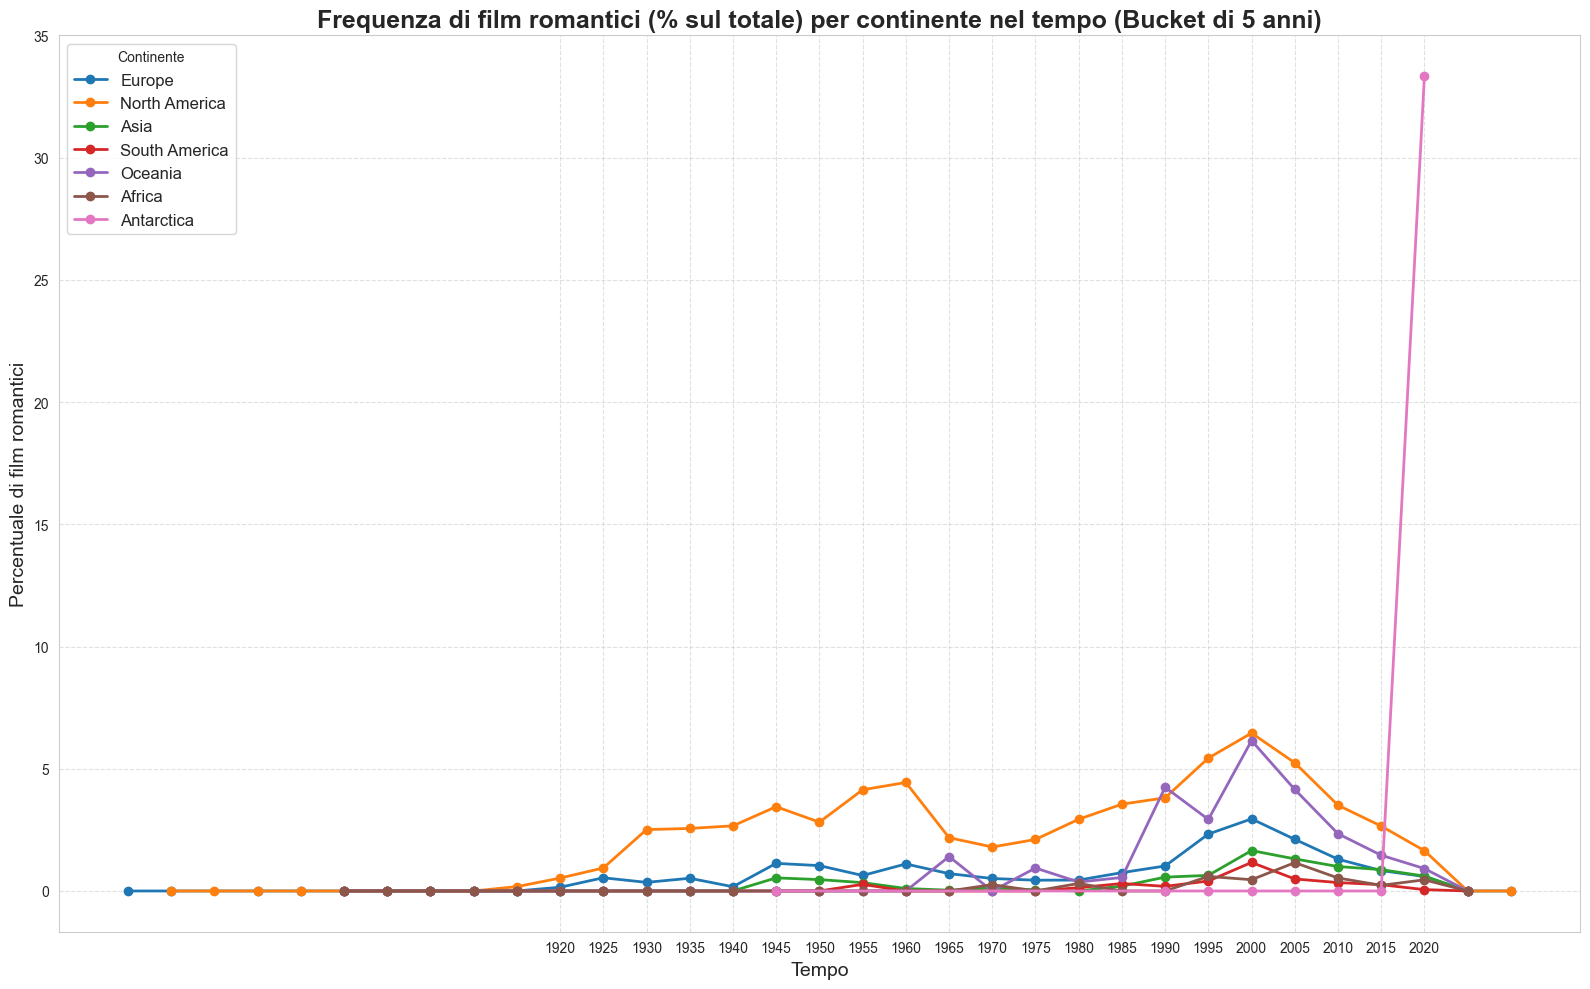

In [ ]:
plt.figure(figsize=(16, 10))
continents = df_romance_country_movies['continent'].unique()

df_continent_total = df_movies_country.groupby('continent')['id'].nunique()

df_romance_country_movies['5_year_bucket'] = df_romance_country_movies['date'].apply(lambda year: (year // 5) * 5)
df_movies_country['5_year_bucket'] = df_movies_country['date'].apply(lambda year: (year // 5) * 5)
for continent in continents:
    continent_romance_counts = df_romance_country_movies[df_romance_country_movies['continent'] == continent].groupby('5_year_bucket')['id_film'].nunique().sort_index()
    if continent in df_continent_total:
        continent_total_counts = df_movies_country[df_movies_country['continent'] == continent].groupby('5_year_bucket')['id'].nunique().sort_index()
        
        combined_index = continent_romance_counts.index.union(continent_total_counts.index)
        continent_romance_counts = continent_romance_counts.reindex(combined_index, fill_value=0)
        continent_total_counts = continent_total_counts.reindex(combined_index, fill_value=0)

        frequency = (continent_romance_counts / continent_total_counts) * 100
        plt.plot(frequency.index, frequency.values, label=continent, linewidth=2, marker='o', markersize=6)

plt.title('Frequenza di film romantici (% sul totale) per continente nel tempo (Bucket di 5 anni)', fontsize=18, fontweight='bold')
plt.xlabel('Tempo', fontsize=14)
plt.ylabel('Percentuale di film romantici', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Continente', fontsize=12)
plt.gca().set_xticks(np.arange(1920, 2025, 5))
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(16, 10))

for continent in continents:
    continent_war_cruelty_counts = df_war_cruelty[df_war_cruelty['continent'] == continent].groupby('5_year_bucket')['id_film'].nunique().sort_index()
    if continent in df_continent_total:
        continent_total_counts = df_movies_country[df_movies_country['continent'] == continent].groupby('5_year_bucket')['id'].nunique().sort_index()

        combined_index = continent_war_cruelty_counts.index.union(continent_total_counts.index)
        continent_war_cruelty_counts = continent_war_cruelty_counts.reindex(combined_index, fill_value=0)
        continent_total_counts = continent_total_counts.reindex(combined_index, fill_value=0)

        frequency = (continent_war_cruelty_counts / continent_total_counts) * 100
        plt.plot(frequency.index, frequency.values, label=continent, linewidth=2, marker='o', markersize=6)

plt.title('Frequenza di film di guerra/crudeltà (% sul totale) per continente nel tempo (Bucket di 5 anni)', fontsize=18, fontweight='bold')
plt.xlabel('Tempo', fontsize=14)
plt.ylabel('Percentuale di film di guerra/crudeltà', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Continente', fontsize=12)
plt.gca().set_xticks(np.arange(1920, 2025, 5))
plt.tight_layout()
plt.show()

KeyError: 'continent'

<Figure size 1600x1000 with 0 Axes>